# Race weekend prediction

One weekend, one stage, every dashboard section. Defaults to the latest weekend whose qualifying
has finished (stage `Q`), so on Saturday evening it produces everything the Sunday page needs:

| section | how it is made |
|---|---|
| weather | Open-Meteo forecast for the race window, FastF1 observed weather for finished sessions |
| circuit | outline from the fastest qualifying lap, length and lap count from telemetry |
| finishing order | XGBoost ranker + DNF classifier (demo hyperparameters) on form and qualifying, Plackett-Luce Monte Carlo |
| race incidents | safety car / VSC / red flag rates from recent races, adjusted for the rain forecast |
| tyre strategy | stint degradation from practice long runs on top of a race-derived prior, simulated over pit plans |
| fun facts | computed from the qualifying result, practice laps and Ergast history |

Datasets land in `data/processed/`, fitted models in `models/`, and the schema-validated JSON the
front end reads in `outputs/site/v1/`.

After the race, sections 11 and 12 grade every prediction against what happened and add post-race facts.
Before the race they stop on purpose, so run them last.

## 0 · Setup

In [1]:
%load_ext autoreload
%autoreload 2

import json
import logging
import sys
import time
import warnings
from datetime import datetime, timezone
from itertools import combinations_with_replacement
from math import ceil
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "nb":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import xgboost as xgb
from IPython.display import display
from scipy.stats import spearmanr

import fastf1
from fastf1.ergast import Ergast
from fastf1.exceptions import ErgastInvalidRequestError

from src import schema
from src.config import FIRST_TIMING_SEASON, MODEL_DIR, OUTPUT_DIR, PROCESSED_DIR, enable_cache
from src.features import weekend_features
from src.long_runs import long_runs
from src.results import collect_pages, establish_api, get_season_results
from src.sessions import get_session_stage, get_sessions
from src.summaries import summarize_session

enable_cache()
logging.getLogger("fastf1").setLevel(logging.WARNING)
# pandas Timestamp + Timedelta trips a NumPy deprecation inside pandas itself; nothing to fix on our side
warnings.filterwarnings("ignore", message="The 'generic' unit for NumPy timedelta")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

FastF1 3.8.3 | cache -> data/fastf1_cache


In [2]:
# The weekend: latest event whose qualifying has finished. Set RACE_ROUND to override.
SEASON = 2026
STAGE = "Q"
RACE_ROUND = None

schedule = fastf1.get_event_schedule(SEASON, include_testing=False)
now = pd.Timestamp.now(tz="UTC").tz_localize(None)
if RACE_ROUND is None:
    RACE_ROUND = int(schedule.loc[schedule["Session4DateUtc"] < now, "RoundNumber"].max())

event = fastf1.get_event(SEASON, RACE_ROUND)
EVENT_FORMAT = event["EventFormat"]
RACE_START = event["Session5DateUtc"].tz_localize("UTC")
assert EVENT_FORMAT in schema.STAGE_ORDER, f"the schema does not publish {EVENT_FORMAT} weekends"

print(f"{SEASON} round {RACE_ROUND}: {event['EventName']} ({event['Location']}, {event['Country']})")
print(f"format {EVENT_FORMAT} | stage {STAGE} | race start {RACE_START:%Y-%m-%d %H:%M} UTC")

2026 round 16: Bahrain Grand Prix (Kuala Lumpur, Bahrain)
format conventional | stage Q | race start 2026-10-04 07:00 UTC


In [3]:
# Where everything is written
WEEKEND = schema.round_dir(SEASON, RACE_ROUND)
WEEKEND_DIR = PROCESSED_DIR / WEEKEND
HISTORY_DIR = PROCESSED_DIR / "history"
MODEL_OUT = MODEL_DIR / f"finishing_order_{SEASON}_r{RACE_ROUND:02d}_{STAGE.lower()}"
SITE_DIR = OUTPUT_DIR / "site" / "v1"
for directory in (WEEKEND_DIR, HISTORY_DIR, MODEL_OUT, SITE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

GENERATED_AT = datetime.now(timezone.utc)
RUN_ID = f"nb-{GENERATED_AT:%Y%m%dT%H%M%SZ}"


def save_csv(frame: pd.DataFrame, path: Path, index=False) -> None:
    frame.to_csv(path, index=index)
    print(f"saved {path.relative_to(ROOT)} ({len(frame)} rows)")

## 1 · Weekend and stage

The stage decides which sessions a prediction may use. The order is derived from the schedule
(`src/sessions.py`) and has to match `schema.STAGE_ORDER`.

In [4]:
weekend_sessions = get_sessions(SEASON, RACE_ROUND)
stage_sessions = get_session_stage(SEASON, RACE_ROUND, STAGE)

# the derived order must equal the order the schema publishes
assert ["pre_weekend", *[s["session_id"] for s in weekend_sessions]] == schema.STAGE_ORDER[EVENT_FORMAT]


def session_status(start_utc, minutes=120) -> str:
    start = pd.Timestamp(start_utc)
    if start + pd.Timedelta(minutes=minutes) < now:
        return "completed"
    return "live" if start <= now else "upcoming"


session_table = pd.DataFrame(weekend_sessions).assign(
    status=lambda t: t["session_dt_utc"].map(session_status),
    usable_at_stage=lambda t: t["session_id"].isin(stage_sessions),
)
assert (session_table.loc[session_table["usable_at_stage"], "status"] == "completed").all(), "a stage session has not finished"
session_table[["session_id", "session_name", "session_dt_utc", "status", "usable_at_stage"]]

,session_id,session_name,session_dt_utc,status,usable_at_stage
0,FP1,Practice 1,2026-10-02 04:30:00,completed,True
1,FP2,Practice 2,2026-10-02 08:00:00,completed,True
2,FP3,Practice 3,2026-10-03 04:30:00,completed,True
3,Q,Qualifying,2026-10-03 08:00:00,completed,True
4,R,Race,2026-10-04 07:00:00,completed,False


## 2 · Weekend sessions

`load_weekend` loads every session including the race, so on a live weekend only the sessions allowed at
the stage are loaded here. Per-session summaries and long runs come from `src/summaries.py` and `src/long_runs.py`.

In [5]:
weekend = {}
for sid in stage_sessions:
    s = fastf1.get_session(SEASON, RACE_ROUND, sid)
    s.load(laps=True, telemetry=False, weather=True, messages=True)
    weekend[sid] = s

summaries = {sid: summarize_session(s) for sid, s in weekend.items()}

session_rows = pd.concat([row for _, row in summaries.values()]).set_index("session")
session_rows[["duration_min", "air_temp_mean", "track_temp_max", "humidity_mean", "wind_speed_mean",
              "rain_frac", "yellow_n", "sc_n", "red_n", "drivers_n"]]

,duration_min,air_temp_mean,track_temp_max,humidity_mean,wind_speed_mean,rain_frac,yellow_n,sc_n,red_n,drivers_n
session,,,,,,,,,,
Practice 1,60.001667,32.586667,58.0,56.358333,1.195000,0.0,0,0,0,22
Practice 2,60.003267,33.220000,59.5,48.275000,1.088333,0.0,2,0,0,22
Practice 3,59.999650,32.660000,59.1,51.035000,1.068333,0.0,2,0,1,22
Qualifying,59.999917,32.758333,58.0,49.485000,0.955000,0.0,0,0,0,22


In [6]:
# Entry list: FastF1 carries the Ergast driver and constructor ids the schema uses as keys
entries = (weekend["Q"].results[["DriverId", "Abbreviation", "DriverNumber", "FirstName", "LastName",
                                 "TeamId", "TeamName", "TeamColor", "HeadshotUrl"]]
           .rename(columns={"DriverId": "driverId", "TeamId": "constructorId"}).reset_index(drop=True))
assert (entries["driverId"] != "").all() and (entries["constructorId"] != "").all()
driver_name = dict(zip(entries["driverId"], entries["FirstName"] + " " + entries["LastName"]))
team_name = dict(zip(entries["constructorId"], entries["TeamName"]))
print(f"{len(entries)} entrants from {entries['constructorId'].nunique()} teams")

22 entrants from 11 teams


In [7]:
# One row per driver with the pace features of every session up to the stage
pace = weekend_features(summaries, stage_sessions)
pace["q_position"] = weekend["Q"].results.set_index("Abbreviation")["Position"]

save_csv(pd.concat([by for by, _ in summaries.values()]), WEEKEND_DIR / "session_by_driver.csv")
save_csv(session_rows.reset_index(), WEEKEND_DIR / "session_summaries.csv")
save_csv(pace.reset_index(), WEEKEND_DIR / "weekend_pace_features.csv")
pace.sort_values("q_position").round(3).head(10)

saved data/processed/2026/16/session_by_driver.csv (88 rows)
saved data/processed/2026/16/session_summaries.csv (4 rows)
saved data/processed/2026/16/weekend_pace_features.csv (22 rows)


,fp1_best_lap_gap_pct,fp1_ideal_lap_gap_pct,fp1_team_gap_pct,fp1_best_lap_rank,fp1_top_speed_rank,fp1_laps_driven,fp1_clean_lap_median,fp1_clean_lap_std,fp2_best_lap_gap_pct,fp2_ideal_lap_gap_pct,fp2_team_gap_pct,fp2_best_lap_rank,fp2_top_speed_rank,fp2_laps_driven,fp2_clean_lap_median,fp2_clean_lap_std,fp3_best_lap_gap_pct,fp3_ideal_lap_gap_pct,fp3_team_gap_pct,fp3_best_lap_rank,fp3_top_speed_rank,fp3_laps_driven,fp3_clean_lap_median,fp3_clean_lap_std,q_best_lap_gap_pct,q_ideal_lap_gap_pct,q_team_gap_pct,q_best_lap_rank,q_top_speed_rank,q_laps_driven,q_clean_lap_median,q_clean_lap_std,q_position
Driver,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
VER,0.000,0.000,0.000,1.0,17.0,23,99.142,0.903,0.264,0.341,0.162,4.0,17.0,20,103.559,2.408,0.289,0.161,0.000,2.0,15.0,12,97.207,0.642,0.000,0.000,0.000,1.0,18.0,12,95.473,0.610,1.0
HAM,1.097,1.097,0.227,6.0,6.0,21,100.173,2.452,0.313,0.390,0.313,5.0,10.0,28,101.006,4.488,0.767,0.767,0.026,6.0,8.0,15,97.832,2.707,0.313,0.449,0.000,2.0,9.0,15,96.032,0.721,2.0
HAD,0.803,0.803,0.803,3.0,15.0,23,99.819,2.258,0.102,0.179,0.000,2.0,8.0,23,99.006,0.873,0.579,0.579,0.290,3.0,17.0,15,97.494,0.668,0.450,0.582,0.450,3.0,16.0,12,95.875,0.638,3.0
ANT,1.087,1.087,0.692,5.0,12.0,23,99.618,0.667,0.545,0.623,0.041,8.0,21.0,28,104.010,0.317,0.000,0.000,0.000,1.0,19.0,12,96.924,0.707,0.527,0.678,0.000,4.0,20.0,12,95.959,0.738,4.0
LEC,0.869,0.853,0.000,4.0,4.0,25,100.045,1.861,0.000,0.000,0.000,1.0,12.0,29,103.055,2.925,0.741,0.577,0.000,5.0,8.0,19,101.208,2.138,0.563,0.666,0.249,5.0,16.0,12,95.924,0.464,5.0
NOR,1.818,1.818,0.017,12.0,19.0,21,102.484,2.192,0.140,0.218,0.000,3.0,17.0,25,99.457,3.423,0.892,0.820,0.000,7.0,13.0,15,98.435,1.050,0.659,0.793,0.000,6.0,15.0,12,96.078,0.586,6.0
PIA,1.801,1.763,0.000,11.0,14.0,23,100.920,2.014,0.380,0.458,0.240,6.0,15.0,26,98.633,0.822,1.105,0.931,0.211,8.0,8.0,16,97.483,0.449,0.664,0.769,0.005,7.0,11.0,12,95.953,0.493,7.0
RUS,0.393,0.393,0.000,2.0,18.0,25,99.153,2.502,0.504,0.268,0.000,7.0,20.0,28,104.315,NaN,0.633,0.430,0.633,4.0,21.0,11,96.982,0.100,0.779,0.819,0.251,8.0,19.0,12,96.138,0.626,8.0
GAS,1.225,1.225,0.000,7.0,7.0,22,100.832,1.119,1.087,1.019,0.000,10.0,17.0,29,99.176,3.026,2.013,1.709,0.328,13.0,3.0,20,98.719,1.808,1.346,1.486,0.000,9.0,4.0,18,97.174,0.513,9.0


In [8]:
# Clean stints per practice session: median pace and degradation slope (src/long_runs.py)
# Practice stints are short at a new circuit, so keep runs of 5+ laps
FP_MIN_LAPS = 5
fp_runs = pd.concat([long_runs(weekend[sid], FP_MIN_LAPS).assign(session=sid)
                     for sid in stage_sessions if sid.startswith("FP")], ignore_index=True)
save_csv(fp_runs, WEEKEND_DIR / "fp_long_runs.csv")
print(fp_runs.groupby(["session", "Compound"]).size().unstack(fill_value=0))

saved data/processed/2026/16/fp_long_runs.csv (47 rows)
Compound  HARD  MEDIUM  SOFT
session                     
FP1          0       6     8
FP2          0      12    15
FP3          1       0     5


## 3 · Circuit

The outline comes from the fastest qualifying lap's position data and is built once per circuit.
FastF1's `get_circuit_info()` has no data for a circuit it has not seen, so corners stay empty.

In [9]:
race_row = Ergast(limit=100).get_race_schedule(season=SEASON, round=RACE_ROUND).iloc[0]
CIRCUIT_ID = race_row["circuitId"]
print(f"{race_row['raceName']} at {race_row['circuitName']} ({CIRCUIT_ID}) | lat {race_row['lat']}, lon {race_row['long']}")

Bahrain Grand Prix in Malaysia at Sepang International Circuit (sepang) | lat 2.76083, lon 101.738


outline 366 points | lap length 5.466 km | race 56 laps (306.1 km)


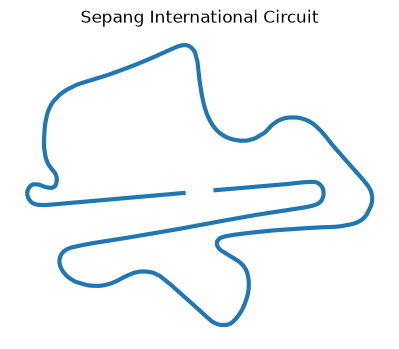

In [10]:
circuit_path = PROCESSED_DIR / "circuits" / f"{CIRCUIT_ID}.csv"
circuit_path.parent.mkdir(parents=True, exist_ok=True)

if circuit_path.exists():
    outline = pd.read_csv(circuit_path)
else:
    tel_session = fastf1.get_session(SEASON, RACE_ROUND, "Q")
    tel_session.load(laps=True, telemetry=True, weather=False, messages=False)
    fastest = tel_session.laps.pick_fastest()
    pos = fastest.get_pos_data()
    distance = fastest.get_car_data().add_distance()["Distance"]

    # rotate into broadcast orientation when FastF1 knows the circuit
    try:
        rotation = tel_session.get_circuit_info().rotation
    except Exception:
        rotation = 0.0
    angle = np.deg2rad(rotation)
    x = pos["X"] * np.cos(angle) + pos["Y"] * np.sin(angle)
    y = -pos["X"] * np.sin(angle) + pos["Y"] * np.cos(angle)

    # unit square with the aspect ratio kept; y flipped because SVG's y axis points down
    scale = max(np.ptp(x), np.ptp(y))
    outline = pd.DataFrame({"x": (x - x.min()) / scale, "y": (y.max() - y) / scale})
    outline["lap_length_km"] = distance.max() / 1000
    outline.to_csv(circuit_path, index=False)

LENGTH_KM = float(outline["lap_length_km"].iloc[0])
# FIA minimum: the fewest laps that cover 305 km
RACE_LAPS = ceil(305 / LENGTH_KM)
print(f"outline {len(outline)} points | lap length {LENGTH_KM:.3f} km | race {RACE_LAPS} laps ({RACE_LAPS * LENGTH_KM:.1f} km)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(outline["x"], 1 - outline["y"], lw=3)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(f"{race_row['circuitName']}")
plt.show()

In [11]:
# Past winners at this circuit (Ergast has them back to 1950; FastF1 timing only from 2018)
api = establish_api()
winners, winner_races = collect_pages(api.get_race_results, circuit=CIRCUIT_ID, results_position=1)
# after the race Ergast lists this weekend's winner too; the page is about the circuit's past
winners = winners[~((winners["season"] == SEASON) & (winners["round"] == RACE_ROUND))]
if winners.empty:
    past_winners = pd.DataFrame(columns=["season", "driver_name", "team_name"])
else:
    past_winners = (winners.assign(driver_name=winners["givenName"] + " " + winners["familyName"],
                                   team_name=winners["constructorName"])
                    .sort_values("season", ascending=False)[["season", "driver_name", "team_name"]])
print(f"{len(past_winners)} past races at {CIRCUIT_ID}; last held in {past_winners['season'].max() if len(past_winners) else None}")
past_winners.head(5)

19 past races at sepang; last held in 2017


,season,driver_name,team_name
18,2017,Max Verstappen,Red Bull
17,2016,Daniel Ricciardo,Red Bull
16,2015,Sebastian Vettel,Ferrari
15,2014,Lewis Hamilton,Mercedes
14,2013,Sebastian Vettel,Red Bull


## 4 · Weather

Open-Meteo for the forecast (FastF1 has none). Sessions that have run use FastF1's observed weather.

race has started: reusing the forecast saved at 2026-10-07 02:42 UTC
saved data/processed/2026/16/weather_hourly.csv (55 rows)
race window 2 h | air 26.2 C | rain chance 71% | wind 1.6 m/s


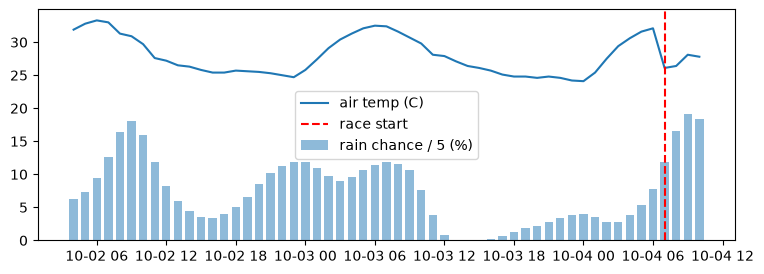

In [12]:
HOURLY_VARS = ["temperature_2m", "precipitation_probability", "precipitation",
               "wind_speed_10m", "wind_direction_10m", "relative_humidity_2m"]


def forecast_hourly(lat, lon, start_date, end_date) -> pd.DataFrame:
    resp = requests.get("https://api.open-meteo.com/v1/forecast", timeout=30, params={
        "latitude": lat, "longitude": lon, "hourly": ",".join(HOURLY_VARS), "wind_speed_unit": "ms",
        "start_date": start_date, "end_date": end_date, "timezone": "UTC"})
    resp.raise_for_status()
    hourly = pd.DataFrame(resp.json()["hourly"])
    hourly["time_utc"] = pd.to_datetime(hourly.pop("time"), utc=True)
    return hourly


WEATHER_PATH = WEEKEND_DIR / "weather_hourly.csv"
if now >= RACE_START.tz_localize(None) and WEATHER_PATH.exists():
    # a forecast cannot be fetched after the fact (Open-Meteo would return what happened), so once the race
    # has started the one saved before it is reused. That keeps a rerun's predictions the pre-race ones
    hourly = pd.read_csv(WEATHER_PATH).assign(time_utc=lambda t: pd.to_datetime(t["time_utc"], utc=True))
    FORECAST_FETCHED_AT = datetime.fromtimestamp(WEATHER_PATH.stat().st_mtime, timezone.utc)
    print(f"race has started: reusing the forecast saved at {FORECAST_FETCHED_AT:%Y-%m-%d %H:%M} UTC")
else:
    first_day = pd.Timestamp(weekend_sessions[0]["session_dt_utc"]).date()
    hourly = forecast_hourly(race_row["lat"], race_row["long"], first_day, RACE_START.date())
    FORECAST_FETCHED_AT = datetime.now(timezone.utc)

# keep the weekend from an hour before first practice to three hours after the race starts
weekend_start = pd.Timestamp(weekend_sessions[0]["session_dt_utc"]).tz_localize("UTC") - pd.Timedelta(hours=1)
hourly = hourly[(hourly["time_utc"] >= weekend_start) & (hourly["time_utc"] <= RACE_START + pd.Timedelta(hours=3))]
save_csv(hourly, WEATHER_PATH)

# rain chance over the race window drives the incident model
race_window = hourly[(hourly["time_utc"] >= RACE_START.floor("h")) & (hourly["time_utc"] < RACE_START + pd.Timedelta(hours=2))]
P_RAIN_RACE = float(race_window["precipitation_probability"].mean() / 100)
print(f"race window {len(race_window)} h | air {race_window['temperature_2m'].mean():.1f} C | "
      f"rain chance {P_RAIN_RACE:.0%} | wind {race_window['wind_speed_10m'].mean():.1f} m/s")

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(hourly["time_utc"], hourly["temperature_2m"], label="air temp (C)")
ax.bar(hourly["time_utc"], hourly["precipitation_probability"] / 5, width=0.03, color="tab:blue", alpha=0.5, label="rain chance / 5 (%)")
ax.axvline(RACE_START, color="red", ls="--", label="race start")
ax.legend()
plt.show()

## 5 · Training data

Ergast race and qualifying results since 2018, one row per driver and race. Every feature is
known at stage `Q`: qualifying (position, gap to pole, teammate delta) and form built in race
order so nothing leaks from the future. Circuit-history features from the Baku demo are left out:
this circuit has no races since 2018, so they would be empty for the whole field.

In [13]:
ERGAST_COLS = {
    "race": ["season", "round", "driverId", "constructorId", "position", "positionText", "points", "grid", "status"],
    "qualifying": ["season", "round", "driverId", "constructorId", "position", "Q1", "Q2", "Q3"],
}


def with_retry(fetch, *args, **kwargs):
    """call a jolpica endpoint, waiting and retrying when it answers 'Too Many Requests'"""
    for attempt in range(6):
        try:
            return fetch(*args, **kwargs)
        except ErgastInvalidRequestError as exc:
            print(f"jolpica refused ({exc.args[0][:50]}...), waiting")
            time.sleep(20 * (attempt + 1))
    raise RuntimeError("jolpica kept refusing the request")


def cached_results(kind: str, years) -> pd.DataFrame:
    """
    Ergast results for several seasons via get_season_results, finished seasons cached
    jolpica allows about 4 requests/s and 500/h, and a season is several pages, so only the
    current season is fetched again; a 'Too Many Requests' answer waits and retries
    qualifying times are stored in seconds
    """
    path = HISTORY_DIR / f"ergast_{kind}.csv"
    cached = pd.read_csv(path) if path.exists() else pd.DataFrame()
    parts = [cached[cached["season"] != SEASON]] if len(cached) else []
    have = set(cached["season"]) if len(cached) else set()
    for year in years:
        if year in have and year < SEASON:
            continue
        results, _ = with_retry(get_season_results, year, kind)
        results = results[ERGAST_COLS[kind]].copy()
        for seg in ("Q1", "Q2", "Q3"):
            if seg in results:
                results[seg] = pd.to_timedelta(results[seg]).dt.total_seconds()
        parts.append(results)
    out = pd.concat(parts, ignore_index=True).sort_values(["season", "round"]).reset_index(drop=True)
    out.to_csv(path, index=False)
    return out


years = range(FIRST_TIMING_SEASON, SEASON + 1)
race_results = cached_results("race", years)
quali_results = cached_results("qualifying", years)
print(f"race rows {len(race_results)} ({race_results.groupby(['season', 'round']).ngroups} races) | "
      f"qualifying rows {len(quali_results)} ({quali_results.groupby(['season', 'round']).ngroups} sessions)")

race rows 3810 (189 races) | qualifying rows 3802 (189 sessions)


In [14]:
def quali_features(quali: pd.DataFrame) -> pd.DataFrame:
    """qualifying position, gap to pole and segments reached, from the Q1/Q2/Q3 times in seconds"""
    q = quali.copy()
    segments = ["Q1", "Q2", "Q3"]
    q["q_best_s"] = q[segments].min(axis=1)
    q["q_segments"] = q[segments].notna().sum(axis=1)
    q["q_gap_pct"] = (q["q_best_s"] / q.groupby(["season", "round"])["q_best_s"].transform("min") - 1) * 100
    q["q_pos"] = q["position"].astype(float)
    return q[["season", "round", "driverId", "constructorId", "q_pos", "q_gap_pct", "q_segments"]]


def mean_or_nan(values):
    return float(np.mean(values)) if len(values) else np.nan


def build_features(race: pd.DataFrame, quali: pd.DataFrame) -> pd.DataFrame:
    """
    one row per driver x race with stage Q features and, where the race has run, the outcome
    races are walked in order: features read the state before the race, then the race updates it,
    so a race with no result yet (the one being predicted) gets features but changes nothing
    """
    q = quali_features(quali)
    outcome = race[["season", "round", "driverId", "constructorId", "position", "positionText", "points", "grid"]]
    rows = outcome.merge(q.drop(columns="constructorId"), on=["season", "round", "driverId"], how="outer")
    # an entry with only a qualifying row is a race that has not been run yet
    team = q.set_index(["season", "round", "driverId"])["constructorId"]
    rows["constructorId"] = rows["constructorId"].fillna(
        pd.Series(rows.set_index(["season", "round", "driverId"]).index.map(team), index=rows.index))
    rows = rows.sort_values(["season", "round", "q_pos"]).reset_index(drop=True)

    rows["finished_race"] = rows["position"].notna()
    rows["dnf"] = np.where(rows["finished_race"], ~rows["positionText"].astype(str).str.isdigit(), np.nan)
    rows["field_size"] = rows.groupby(["season", "round"])["driverId"].transform("size")

    # qualifying context from the same session: team pace and the delta to the teammate
    by_team = rows.groupby(["season", "round", "constructorId"])
    rows["team_q_gap_pct"] = by_team["q_gap_pct"].transform("mean")
    team_q_sum, team_n = by_team["q_pos"].transform("sum"), by_team["q_pos"].transform("size")
    rows["teammate_q_delta"] = (rows["q_pos"] - (team_q_sum - rows["q_pos"]) / (team_n - 1)).where(team_n > 1)

    from collections import defaultdict, deque
    drivers = defaultdict(lambda: deque(maxlen=10))
    teams = defaultdict(lambda: deque(maxlen=10))
    feats = []
    for _, race_rows in rows.groupby(["season", "round"], sort=True):
        for r in race_rows.itertuples():
            d, t = list(drivers[r.driverId]), list(teams[r.constructorId])
            d5, t5 = d[-5:], t[-5:]
            feats.append({
                "driver_finish_5": mean_or_nan([x["finish"] for x in d5]),
                "driver_points_5": mean_or_nan([x["points"] for x in d5]),
                "driver_podium_rate_5": mean_or_nan([x["podium"] for x in d5]),
                "driver_gain_5": mean_or_nan([x["gain"] for x in d5 if not np.isnan(x["gain"])]),
                "driver_dnf_rate_10": mean_or_nan([x["dnf"] for x in d]),
                "driver_history_count": len(d5),
                "team_points_5": mean_or_nan([x["points"] for x in t5]),
                "team_finish_5": mean_or_nan([x["finish"] for x in t5]),
                "team_dnf_rate_10": mean_or_nan([x["dnf"] for x in t]),
            })
        done = race_rows[race_rows["finished_race"]]
        for r in done.itertuples():
            drivers[r.driverId].append({"finish": float(r.position), "points": float(r.points),
                                        "podium": int(r.position <= 3), "gain": r.q_pos - r.position,
                                        "dnf": int(r.dnf)})
        for team_id, g in done.groupby("constructorId"):
            teams[team_id].append({"finish": g["position"].mean(), "points": g["points"].sum(),
                                   "dnf": g["dnf"].mean()})
    return pd.concat([rows, pd.DataFrame(feats, index=rows.index)], axis=1)


# only races that have run and the race being predicted
target = (quali_results["season"] == SEASON) & (quali_results["round"] == RACE_ROUND)
assert target.any(), "qualifying results for the target race are not in Ergast yet"
race_done = race_results[(race_results["season"] < SEASON) | (race_results["round"] < RACE_ROUND)]
quali_used = quali_results[(quali_results["season"] < SEASON) | (quali_results["round"] <= RACE_ROUND)]

rows = build_features(race_done, quali_used)
rows["race_id"] = rows["season"].astype(str) + "-" + rows["round"].astype(str).str.zfill(2)

FEATURES = ["q_pos", "q_gap_pct", "q_segments", "team_q_gap_pct", "teammate_q_delta", "field_size",
            "driver_finish_5", "driver_gain_5", "driver_points_5", "driver_podium_rate_5", "driver_dnf_rate_10",
            "driver_history_count", "team_points_5", "team_finish_5", "team_dnf_rate_10"]

# the first timing season only warms up the form features
train_rows = rows[rows["finished_race"] & (rows["season"] > FIRST_TIMING_SEASON)].copy()
predict_rows = rows[(rows["season"] == SEASON) & (rows["round"] == RACE_ROUND)].copy()
assert not predict_rows["finished_race"].any()
print(f"training rows {len(train_rows)} ({train_rows['race_id'].nunique()} races, {train_rows['season'].min()}-{train_rows['season'].max()}) "
      f"| prediction rows {len(predict_rows)}")

save_csv(rows, HISTORY_DIR / "finishing_features.csv")
save_csv(predict_rows, WEEKEND_DIR / "finishing_features.csv")
predict_rows[["driverId", "constructorId", *FEATURES]].round(2).head(8)

training rows 3368 (167 races, 2019-2026) | prediction rows 22
saved data/processed/history/finishing_features.csv (3811 rows)
saved data/processed/2026/16/finishing_features.csv (22 rows)


,driverId,constructorId,q_pos,q_gap_pct,q_segments,team_q_gap_pct,teammate_q_delta,field_size,driver_finish_5,driver_gain_5,driver_points_5,driver_podium_rate_5,driver_dnf_rate_10,driver_history_count,team_points_5,team_finish_5,team_dnf_rate_10
3789,max_verstappen,red_bull,1.0,0.00,3.0,0.22,-2.0,22,6.2,-0.2,13.8,0.8,0.2,5,21.2,6.7,0.10
3790,hamilton,ferrari,2.0,0.31,3.0,0.44,-3.0,22,8.6,-4.2,7.6,0.0,0.1,5,16.8,8.2,0.15
3791,hadjar,red_bull,3.0,0.45,3.0,0.22,2.0,22,5.2,1.8,9.8,0.2,0.1,5,21.2,6.7,0.10
3792,antonelli,mercedes,4.0,0.53,3.0,0.65,-4.0,22,2.4,4.0,18.6,0.8,0.0,5,33.4,3.0,0.05
3793,leclerc,ferrari,5.0,0.56,3.0,0.44,3.0,22,7.8,-3.8,9.2,0.0,0.2,5,16.8,8.2,0.15
3794,norris,mclaren,6.0,0.66,3.0,0.66,-1.0,22,5.6,-2.2,15.4,0.6,0.2,5,19.8,8.0,0.15
3795,piastri,mclaren,7.0,0.66,3.0,0.66,1.0,22,10.4,-6.0,4.4,0.0,0.1,5,19.8,8.0,0.15
3796,russell,mercedes,8.0,0.78,3.0,0.65,4.0,22,3.6,0.0,14.8,0.6,0.1,5,33.4,3.0,0.05


## 6 · Finishing order model

The Baku demo's XGBoost settings (120 shallow trees, strong L2, `min_child_weight` 5), used two ways:

- an **`XGBRanker`** (NDCG objective, so the top of the order counts most) learns the finishing order within a race, so every position gets a score and not just the winner
- an **`XGBClassifier`** predicts the chance a car is not classified

Scores become position probabilities by Plackett-Luce Monte Carlo. 2026 changed the cars, so races are
weighted by `0.6 ** seasons_ago`. Pre-2026 form acts as a prior, not an equal vote.

In [15]:
XGB_PARAMS = dict(n_estimators=120, max_depth=3, learning_rate=0.06, reg_lambda=5.0,
                  min_child_weight=5, tree_method="hist", n_jobs=2, random_state=42)
RECENCY = 0.6


def fit_models(train: pd.DataFrame, ref_season: int):
    """ranker for the order among classified cars, classifier for P(not classified)"""
    train = train.sort_values(["season", "round", "q_pos"])
    season_weight = RECENCY ** (ref_season - train["season"].to_numpy())
    # a ranker takes one weight per race, and the groups must be contiguous
    group_codes, group_ids = pd.factorize(train["race_id"])
    group_weight = pd.Series(season_weight).groupby(group_codes).first().to_numpy()

    relevance = (train["field_size"] - train["position"]).astype(int)
    ranker = xgb.XGBRanker(objective="rank:ndcg", ndcg_exp_gain=False, **XGB_PARAMS)
    ranker.fit(train[FEATURES], relevance, qid=group_codes, sample_weight=group_weight)

    dnf_model = xgb.XGBClassifier(objective="binary:logistic", eval_metric="logloss", **XGB_PARAMS)
    dnf_model.fit(train[FEATURES], train["dnf"].astype(int), sample_weight=season_weight)
    return ranker, dnf_model


def predict_scores(ranker, dnf_model, frame: pd.DataFrame) -> pd.DataFrame:
    return frame[["season", "round", "driverId", "q_pos"]].assign(
        score=ranker.predict(frame[FEATURES]),
        p_dnf_model=dnf_model.predict_proba(frame[FEATURES])[:, 1])

In [16]:
# Expanding-window backtest: every 2025 and 2026 race is predicted by a model that has seen only earlier races
BACKTEST_FROM = SEASON - 1
test_races = (train_rows[train_rows["season"] >= BACKTEST_FROM][["season", "round"]]
              .drop_duplicates().itertuples(index=False, name=None))

backtest = []
for season, rnd in test_races:
    before = train_rows[(train_rows["season"] < season) | ((train_rows["season"] == season) & (train_rows["round"] < rnd))]
    test = train_rows[(train_rows["season"] == season) & (train_rows["round"] == rnd)]
    ranker, dnf_model = fit_models(before, season)
    backtest.append(predict_scores(ranker, dnf_model, test).assign(
        position=test["position"].to_numpy(), dnf=test["dnf"].to_numpy(), field_size=test["field_size"].to_numpy()))
backtest = pd.concat(backtest, ignore_index=True)
print(f"backtest: {backtest.groupby(['season', 'round']).ngroups} races, {len(backtest)} driver rows")

backtest: 39 races, 809 driver rows


In [17]:
def simulate_finish(scores, p_dnf, temperature, n_sims, rng):
    """
    Monte Carlo races: each car retires with p_dnf, the rest finish in Plackett-Luce order
    (Gumbel-perturbed scores). Returns position counts (cars x positions) and retirement counts
    """
    n = len(scores)
    retired = rng.random((n_sims, n)) < p_dnf
    perf = scores / temperature + rng.gumbel(size=(n_sims, n))
    perf[retired] = -np.inf
    order = np.argsort(-perf, axis=1)                      # car index at each position
    counts = np.zeros((n, n))
    for pos in range(n):
        finisher = ~retired[np.arange(n_sims), order[:, pos]]
        counts[:, pos] = np.bincount(order[finisher, pos], minlength=n)
    return counts, retired.sum(axis=0)


def backtest_probs(temperature: float, n_sims: int, seed: int = 0) -> pd.DataFrame:
    """P(win) and P(podium) for every backtest driver, next to what happened"""
    rng = np.random.default_rng(seed)
    parts = []
    for _, g in backtest.groupby(["season", "round"]):
        counts, _ = simulate_finish(g["score"].to_numpy(), g["p_dnf_model"].to_numpy(), temperature, n_sims, rng)
        probs = counts / n_sims
        parts.append(g.assign(
            p_win=probs[:, 0], p_podium=probs[:, :3].sum(axis=1),
            y_win=((g["position"] == 1) & (g["dnf"] == 0)).astype(float),
            y_podium=((g["position"] <= 3) & (g["dnf"] == 0)).astype(float)))
    return pd.concat(parts, ignore_index=True)

In [18]:
# Temperature: how sharply a score gap turns into a likelier finish. One scalar, chosen to minimise the
# Brier score of the two numbers the dashboard leads with (P(win) and P(podium)) over the backtest
def brier_pair(frame: pd.DataFrame) -> tuple[float, float]:
    return (float(((frame["p_win"] - frame["y_win"]) ** 2).mean()),
            float(((frame["p_podium"] - frame["y_podium"]) ** 2).mean()))


temperature_grid = [0.15, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]
grid_scores = {t: brier_pair(backtest_probs(t, 3000)) for t in temperature_grid}
TEMPERATURE = min(grid_scores, key=lambda t: sum(grid_scores[t]))
print("temperature -> Brier (win, podium)")
for t, (bw, bp) in grid_scores.items():
    print(f"  {t:<4} {bw:.4f} {bp:.4f}{'  <- chosen' if t == TEMPERATURE else ''}")

temperature -> Brier (win, podium)
  0.15 0.0267 0.0622
  0.2  0.0259 0.0607
  0.3  0.0252 0.0595  <- chosen
  0.4  0.0257 0.0596
  0.5  0.0267 0.0604
  0.7  0.0293 0.0631
  1.0  0.0330 0.0690


In [19]:
# Grade the backtest against the naive way to read qualifying
def race_metrics(g: pd.DataFrame) -> dict:
    fin = g[g["dnf"] == 0]
    pred_rank = fin["score"].rank(ascending=False)
    grid_rank = fin["q_pos"].rank()
    actual_top3 = set(fin.nsmallest(3, "position")["driverId"])
    top3 = lambda rank: set(fin.loc[rank.nsmallest(3).index, "driverId"])
    return {
        "spearman_model": spearmanr(pred_rank, fin["position"])[0],
        "spearman_grid": spearmanr(grid_rank, fin["position"])[0],
        "winner_model": float(fin.loc[pred_rank.idxmin(), "position"] == 1),
        "winner_grid": float(fin.loc[grid_rank.idxmin(), "position"] == 1),
        "top3_model": len(top3(pred_rank) & actual_top3) / 3,
        "top3_grid": len(top3(grid_rank) & actual_top3) / 3,
        "mae_model": (pred_rank - fin["position"]).abs().mean(),
        "mae_grid": (grid_rank - fin["position"]).abs().mean(),
    }


# classified cars only, so the model and the grid are ranked on the same drivers
per_race = pd.DataFrame([race_metrics(g) for _, g in backtest.groupby(["season", "round"])])
order_metrics = per_race.mean()
display(pd.DataFrame(
    {"model": order_metrics.filter(like="_model").to_numpy(), "qualifying order": order_metrics.filter(like="_grid").to_numpy()},
    index=["rank correlation", "winner hit rate", "top-3 overlap", "mean position error"]).round(3))

,model,qualifying order
rank correlation,0.782,0.761
winner hit rate,0.667,0.718
top-3 overlap,0.735,0.726
mean position error,2.219,2.276


Brier win    0.0254 vs grid-slot rate 0.0257
Brier podium 0.0593 vs grid-slot rate 0.0623
expected calibration error (podium) 0.028 over 809 driver-races


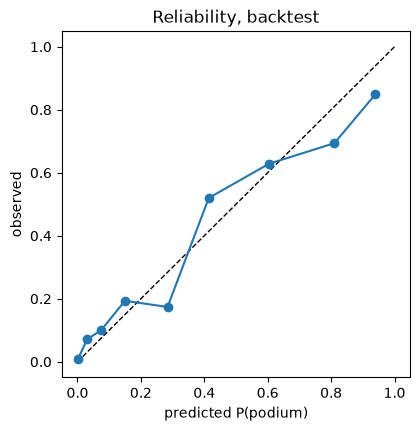

,n,predicted,observed
p_podium,,,
"(-0.001, 0.02]",551,0.002,0.009
"(0.02, 0.05]",42,0.031,0.071
"(0.05, 0.1]",20,0.074,0.100
"(0.1, 0.2]",31,0.150,0.194
"(0.2, 0.35]",23,0.284,0.174
"(0.35, 0.5]",25,0.414,0.520
"(0.5, 0.7]",35,0.604,0.629
"(0.7, 0.9]",49,0.810,0.694
"(0.9, 1.0]",33,0.939,0.848


In [20]:
# Probabilities: the baseline is the historical win / podium rate of the grid slot, from seasons before the backtest
history_before = train_rows[train_rows["season"] < BACKTEST_FROM]
slot_rate = (history_before.assign(win=(history_before["position"] == 1) & (history_before["dnf"] == 0),
                                   podium=(history_before["position"] <= 3) & (history_before["dnf"] == 0))
             .groupby("q_pos")[["win", "podium"]].mean())

prob_bt = backtest_probs(TEMPERATURE, 4000)
brier = dict(zip(("win", "podium"), brier_pair(prob_bt)))
base = prob_bt.assign(p_win=slot_rate["win"].reindex(prob_bt["q_pos"]).fillna(0).to_numpy(),
                      p_podium=slot_rate["podium"].reindex(prob_bt["q_pos"]).fillna(0).to_numpy())
brier_base = dict(zip(("win", "podium"), brier_pair(base)))
print(f"Brier win    {brier['win']:.4f} vs grid-slot rate {brier_base['win']:.4f}")
print(f"Brier podium {brier['podium']:.4f} vs grid-slot rate {brier_base['podium']:.4f}")

# reliability of P(podium): predicted vs observed by bin
bins = pd.cut(prob_bt["p_podium"], [0, .02, .05, .1, .2, .35, .5, .7, .9, 1.0], include_lowest=True)
reliability = prob_bt.groupby(bins, observed=True).agg(n=("y_podium", "size"), predicted=("p_podium", "mean"), observed=("y_podium", "mean"))
ece = float((reliability["n"] * (reliability["predicted"] - reliability["observed"]).abs()).sum() / reliability["n"].sum())
print(f"expected calibration error (podium) {ece:.3f} over {len(prob_bt)} driver-races")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.plot(reliability["predicted"], reliability["observed"], "o-")
ax.set_xlabel("predicted P(podium)")
ax.set_ylabel("observed")
ax.set_title("Reliability, backtest")
plt.show()
reliability.round(3)

In [21]:
# Final fit on every race before this one, then score the field
ranker, dnf_model = fit_models(train_rows, SEASON)
scored = predict_scores(ranker, dnf_model, predict_rows).merge(
    predict_rows[["driverId", "constructorId"]], on="driverId")

N_SIMS = 40_000
counts, retired_counts = simulate_finish(scored["score"].to_numpy(), scored["p_dnf_model"].to_numpy(),
                                         TEMPERATURE, N_SIMS, np.random.default_rng(RACE_ROUND))
position_probs = counts / N_SIMS
# p_dnf from the simulation itself, so each row sums to exactly 1 as the schema requires
scored["p_dnf"] = retired_counts / N_SIMS
n_cars = len(scored)
scored["p_win"] = position_probs[:, 0]
scored["p_podium"] = position_probs[:, :3].sum(axis=1)
scored["p_points"] = position_probs[:, :10].sum(axis=1)
scored["expected_position"] = (position_probs * np.arange(1, n_cars + 1)).sum(axis=1) / position_probs.sum(axis=1)

# predicted order; the probability rows move with their drivers
by_expected = scored["expected_position"].argsort().to_numpy()
scored = scored.iloc[by_expected].reset_index(drop=True)
position_probs = position_probs[by_expected]

prediction = scored[["driverId", "constructorId", "q_pos", "score", "p_win", "p_podium", "p_points", "p_dnf", "expected_position"]]
print(f"field {n_cars} cars | probabilities sum: win {prediction['p_win'].sum():.3f}, podium {prediction['p_podium'].sum():.3f}")
display(prediction.round(3).head(12))

field 22 cars | probabilities sum: win 1.000, podium 3.000


,driverId,constructorId,q_pos,score,p_win,p_podium,p_points,p_dnf,expected_position
0,hamilton,ferrari,2.0,1.570,0.506,0.937,0.946,0.054,1.588
1,max_verstappen,red_bull,1.0,1.482,0.360,0.893,0.910,0.090,1.804
2,antonelli,mercedes,4.0,1.083,0.107,0.794,0.945,0.055,2.737
3,leclerc,ferrari,5.0,0.327,0.008,0.112,0.910,0.090,4.974
4,hadjar,red_bull,3.0,0.315,0.008,0.106,0.898,0.102,5.017
5,norris,mclaren,6.0,0.296,0.007,0.093,0.865,0.135,5.124
6,russell,mercedes,8.0,-0.018,0.003,0.035,0.881,0.117,6.322
7,piastri,mclaren,7.0,-0.190,0.001,0.020,0.859,0.134,7.009
8,gasly,alpine,9.0,-0.706,0.000,0.004,0.654,0.170,9.116
9,bortoleto,audi,10.0,-0.755,0.000,0.004,0.648,0.132,9.321


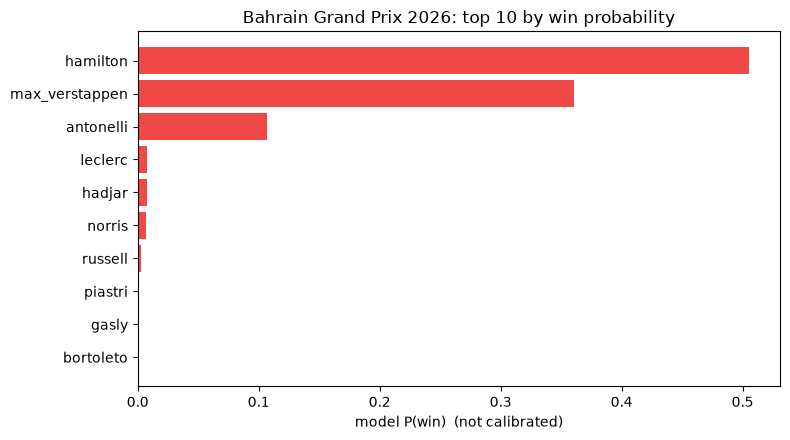

In [22]:
fig, ax = plt.subplots(figsize=(8, 4.5))
top = prediction.head(10).iloc[::-1]
ax.barh(top["driverId"], top["p_win"], color="#F04747")
ax.set_xlabel("model P(win)  (not calibrated)")
ax.set_title(f"{event['EventName']} {SEASON}: top 10 by win probability")
plt.tight_layout()
plt.show()

In [23]:
# Persist the dataset, the predictions and the fitted models
order = prediction["driverId"].tolist()
position_table = pd.DataFrame(position_probs, columns=[f"P{k + 1}" for k in range(n_cars)],
                              index=scored["driverId"]).reindex(order)
save_csv(prediction, WEEKEND_DIR / "finishing_predictions.csv")
save_csv(position_table.reset_index(), WEEKEND_DIR / "finishing_position_probs.csv")
save_csv(prob_bt.drop(columns=[c for c in prob_bt if c.startswith("base_")]), HISTORY_DIR / f"finishing_backtest_{SEASON}_r{RACE_ROUND:02d}.csv")

# date of the last race the models have seen
prev_races = schedule[schedule["RoundNumber"] < RACE_ROUND]
TRAINED_THROUGH = (prev_races["Session5DateUtc"].max() if len(prev_races) else pd.Timestamp(f"{SEASON - 1}-12-31")).date()

ranker.save_model(MODEL_OUT / "ranker.json")
dnf_model.save_model(MODEL_OUT / "dnf.json")
print(f"saved models in {MODEL_OUT.relative_to(ROOT)}")

# metrics, settings and both models in one bundle, the way the Baku demo shipped its model
BACKTEST_LABEL = (f"{BACKTEST_FROM}-{SEASON}, {backtest.groupby(['season', 'round']).ngroups} races, "
                  f"expanding window, predictions at stage {STAGE}")
metrics = [
    schema.Metric(name="rank_correlation", value=float(order_metrics["spearman_model"]), lower_is_better=False,
                  baseline_name="qualifying_order", baseline_value=float(order_metrics["spearman_grid"]), evaluated_on=BACKTEST_LABEL),
    schema.Metric(name="winner_hit_rate", value=float(order_metrics["winner_model"]), lower_is_better=False,
                  baseline_name="qualifying_order", baseline_value=float(order_metrics["winner_grid"]), evaluated_on=BACKTEST_LABEL),
    schema.Metric(name="top3_overlap", value=float(order_metrics["top3_model"]), lower_is_better=False,
                  baseline_name="qualifying_order", baseline_value=float(order_metrics["top3_grid"]), evaluated_on=BACKTEST_LABEL),
    schema.Metric(name="mean_position_error", value=float(order_metrics["mae_model"]), lower_is_better=True,
                  baseline_name="qualifying_order", baseline_value=float(order_metrics["mae_grid"]), evaluated_on=BACKTEST_LABEL),
    schema.Metric(name="brier_win", value=brier["win"], lower_is_better=True,
                  baseline_name="grid_slot_rate", baseline_value=brier_base["win"], evaluated_on=BACKTEST_LABEL),
    schema.Metric(name="brier_podium", value=brier["podium"], lower_is_better=True,
                  baseline_name="grid_slot_rate", baseline_value=brier_base["podium"], evaluated_on=BACKTEST_LABEL),
    schema.Metric(name="calibration_error_podium", value=ece, lower_is_better=True, evaluated_on=BACKTEST_LABEL),
]
metadata = {
    "season": SEASON, "round": RACE_ROUND, "stage": STAGE, "run_id": RUN_ID,
    "trained_through": TRAINED_THROUGH.isoformat(), "features": FEATURES, "xgboost_params": XGB_PARAMS,
    "recency_weight": RECENCY, "plackett_luce_temperature": TEMPERATURE, "n_sims": N_SIMS,
    "score_label": "model score; not a calibrated probability",
    "backtest": [m.model_dump() for m in metrics],
}
(MODEL_OUT / "metadata.json").write_text(json.dumps(metadata, indent=2))
joblib.dump({"ranker": ranker, "dnf_model": dnf_model, "features": FEATURES,
             "temperature": TEMPERATURE, "metadata": metadata}, MODEL_OUT / "bundle.joblib")
print(f"saved bundle and metadata in {MODEL_OUT.relative_to(ROOT)}")

saved data/processed/2026/16/finishing_predictions.csv (22 rows)
saved data/processed/2026/16/finishing_position_probs.csv (22 rows)
saved data/processed/history/finishing_backtest_2026_r16.csv (809 rows)
saved models in models/finishing_order_2026_r16_q
saved bundle and metadata in models/finishing_order_2026_r16_q


## 7 · Race incidents

Safety car, VSC and red flag rates come from recent races (`summarize_session` on each race, the same
counting rule as the label definition in `docs/pipeline-plan.md`). There is no history at this circuit,
so the rates are season-wide, with the wet-race rate shrunk toward the all-race rate and weighted by the
rain forecast. Each race is loaded once and stored in `data/processed/history/`, so a rerun only fetches new races.

In [24]:
HISTORY_SEASONS = (SEASON - 1, SEASON)
INCIDENT_PATH = HISTORY_DIR / "race_incidents.csv"
STINT_PATH = HISTORY_DIR / "race_stints.csv"
RUN_PATH = HISTORY_DIR / "race_long_runs.csv"


def load_race_history(year: int, rnd: int):
    """one race -> incident summary row, stint table and clean-stint degradation slopes"""
    s = fastf1.get_session(year, rnd, "R")
    s.load(laps=True, telemetry=False, weather=True, messages=True)
    _, summary = summarize_session(s)
    laps = s.laps

    # a safety car period starts on the first lap of each run of consecutive SC laps
    sc_laps = np.sort(laps.loc[laps["TrackStatus"].str.contains("4", na=False), "LapNumber"].unique())
    sc_starts = sc_laps[np.r_[True, np.diff(sc_laps) > 1]] if len(sc_laps) else []

    stints = (laps.groupby(["Driver", "Stint", "Compound"])
              .agg(start_lap=("LapNumber", "min"), end_lap=("LapNumber", "max")).reset_index())
    stints["is_final"] = stints["Stint"] == stints.groupby("Driver")["Stint"].transform("max")

    keys = {"season": year, "round": rnd}
    incident = summary.assign(total_laps=int(s.total_laps), sc_start_laps=json.dumps([int(x) for x in sc_starts]),
                              event_name=s.event["EventName"])
    return incident, stints.assign(**keys), long_runs(s, min_laps=10).assign(**keys)


def read_or_empty(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


incidents_all, stints_all, runs_all = read_or_empty(INCIDENT_PATH), read_or_empty(STINT_PATH), read_or_empty(RUN_PATH)
stored = set(zip(incidents_all["season"], incidents_all["round"])) if len(incidents_all) else set()

todo = []
for year in HISTORY_SEASONS:
    season_schedule = schedule if year == SEASON else fastf1.get_event_schedule(year, include_testing=False)
    for rnd in season_schedule.loc[season_schedule["Session5DateUtc"] < now, "RoundNumber"].astype(int):
        if (year, rnd) not in stored and not (year == SEASON and rnd >= RACE_ROUND):
            todo.append((year, rnd))
print(f"{len(stored)} races stored, {len(todo)} to load")

for year, rnd in todo:
    try:
        incident, stints, runs = load_race_history(year, rnd)
    except fastf1.exceptions.RateLimitExceededError:
        print("FastF1 rate limit reached, rerun later to load the rest")
        break
    except Exception as exc:
        print(f"skipped {year} round {rnd}: {exc!r}")
        continue
    incidents_all = pd.concat([incidents_all, incident], ignore_index=True)
    stints_all = pd.concat([stints_all, stints], ignore_index=True)
    runs_all = pd.concat([runs_all, runs], ignore_index=True)
    incidents_all.to_csv(INCIDENT_PATH, index=False)
    stints_all.to_csv(STINT_PATH, index=False)
    runs_all.to_csv(RUN_PATH, index=False)

labels = pd.read_csv(INCIDENT_PATH)
labels["wet"] = labels["rain_frac"] > 0
print(f"{len(labels)} races | with a safety car {(labels['sc_n'] > 0).mean():.0%} | VSC {(labels['vsc_n'] > 0).mean():.0%} "
      f"| red flag {(labels['red_n'] > 0).mean():.0%} | wet {labels['wet'].mean():.0%}")
labels[["season", "round", "event_name", "total_laps", "sc_n", "vsc_n", "red_n", "rain_frac"]].tail(6)

39 races stored, 0 to load
39 races | with a safety car 54% | VSC 49% | red flag 8% | wet 10%


,season,round,event_name,total_laps,sc_n,vsc_n,red_n,rain_frac
33,2026,10,Belgian Grand Prix,44,1,2,0,0.000
34,2026,11,Hungarian Grand Prix,70,0,1,0,0.000
35,2026,12,Dutch Grand Prix,72,0,2,1,0.104
36,2026,13,Italian Grand Prix,53,1,1,1,0.000
37,2026,14,Spanish Grand Prix,57,0,1,0,0.000
38,2026,15,Azerbaijan Grand Prix,51,2,0,0,0.000


In [25]:
INCIDENT_COLS = {"safety_car": "sc_n", "vsc": "vsc_n", "red_flag": "red_n"}


def incident_rates(p_wet: float, shrink: float = 5.0) -> dict:
    """
    P(at least one) and expected count per incident type for a race that is wet with probability p_wet
    wet and dry races each get their own rate, shrunk toward the all-race rate by their sample size,
    so a handful of wet races does not swing the number
    """
    out = {}
    for name, col in INCIDENT_COLS.items():
        has, count = (labels[col] > 0).astype(float), labels[col].astype(float)
        p_all, m_all = (has.sum() + 1) / (len(labels) + 2), count.mean()   # Beta(1, 1) smoothing
        by_wet = {}
        for wet in (False, True):
            subset = labels["wet"] == wet
            w = subset.sum() / (subset.sum() + shrink)
            by_wet[wet] = (w * has[subset].mean() + (1 - w) * p_all if subset.any() else p_all,
                           w * count[subset].mean() + (1 - w) * m_all if subset.any() else m_all)
        p = (1 - p_wet) * by_wet[False][0] + p_wet * by_wet[True][0]
        mean = (1 - p_wet) * by_wet[False][1] + p_wet * by_wet[True][1]
        out[name] = {"p": float(p), "expected": float(max(mean, p))}
    return out


rates = incident_rates(P_RAIN_RACE)
P_SC = rates["safety_car"]["p"]
display(pd.DataFrame(rates).T.round(3).rename(columns={"p": "P(at least one)", "expected": "expected number"}))
print(f"rain chance in the race window {P_RAIN_RACE:.0%}")

,P(at least one),expected number
safety_car,0.527,0.889
vsc,0.563,1.087
red_flag,0.135,0.135


rain chance in the race window 71%


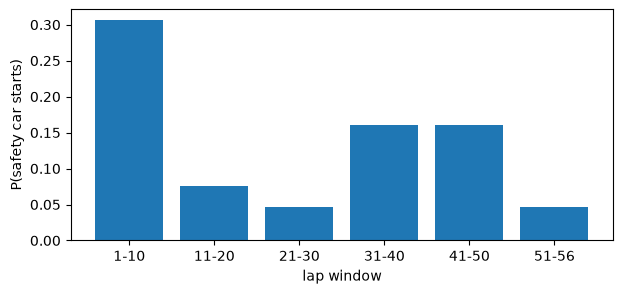

saved data/processed/2026/16/incident_windows.csv (6 rows)


,start_lap,end_lap,n_history,p_safety_car
0,1,10,11,0.306
1,11,20,2,0.076
2,21,30,1,0.046
3,31,40,5,0.160
4,41,50,5,0.160
5,51,56,1,0.046


In [26]:
# Where the safety car comes out: start laps from past races, as a share of race distance
WINDOW = 10
starts = [(rel, row.total_laps) for row in labels.itertuples() for rel in json.loads(row.sc_start_laps)]
relative_start = np.array([(lap - 1) / total for lap, total in starts])
windows = [(a, min(a + WINDOW - 1, RACE_LAPS)) for a in range(1, RACE_LAPS + 1, WINDOW)]

window_rows = []
for a, b in windows:
    in_window = ((relative_start >= (a - 1) / RACE_LAPS) & (relative_start < b / RACE_LAPS)).sum()
    # half a count of smoothing per window so an empty window is not impossible
    share = (in_window + 0.5) / (len(relative_start) + 0.5 * len(windows))
    p_window = min(P_SC, 1 - np.exp(-rates["safety_car"]["expected"] * share))
    window_rows.append({"start_lap": a, "end_lap": b, "n_history": int(in_window), "p_safety_car": float(p_window)})
window_table = pd.DataFrame(window_rows)

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(window_table["start_lap"].astype(str) + "-" + window_table["end_lap"].astype(str), window_table["p_safety_car"])
ax.set_ylabel("P(safety car starts)")
ax.set_xlabel("lap window")
plt.show()

history_by_season = (labels.groupby("season")[["sc_n", "vsc_n", "red_n"]].sum()
                     .rename(columns={"sc_n": "safety_cars", "vsc_n": "vscs", "red_n": "red_flags"}))
incident_summary = {"rates": rates, "p_rain_race": P_RAIN_RACE, "race_laps": RACE_LAPS, "windows": window_rows,
                    "history_races": len(labels)}
(WEEKEND_DIR / "incident_rates.json").write_text(json.dumps(incident_summary, indent=2))
save_csv(window_table, WEEKEND_DIR / "incident_windows.csv")
window_table.round(3)

## 8 · Tyre strategy

Race time of a plan is the sum of its stints plus pit losses, and fuel burn cancels between plans, so each
compound needs only two numbers: a pace offset and a degradation slope.

- **Degradation.** Prior from the clean race stints stored above (era level, spread across races), updated
  with this weekend's practice long runs by a normal-normal update. Practice slopes include fuel burn, so a
  fixed fuel-gain prior (about 0.03 s/kg) is added back. Short practice runs say less about a race than their
  scatter suggests (fuel, engine modes, push laps), so each practice mean also carries a transfer variance.
- **Pace offsets.** Priors of half a second per compound step (the compound spread at most circuits),
  updated with the same-driver, same-session practice pairs where they exist, with the same transfer variance.
  No Pirelli allocation is in FastF1.
- **Stint caps** are the 90th percentile of non-final stint lengths in dry races.
- **Pit loss** is the median Ergast pit-lane time over the stored races, which overstates the true loss a little.
- A safety car can land on any lap and makes a stop 40% cheaper if it falls within five laps.

Everything here is dry running. The strategy document says nothing about rain, so read it with the weather panel.

In [27]:
DRY = ["SOFT", "MEDIUM", "HARD"]
stints_all = pd.read_csv(STINT_PATH)
runs_all = pd.read_csv(RUN_PATH)

dry_races = labels.loc[~labels["wet"] & (labels["wet_laps_frac"] < 0.02), ["season", "round"]]
dry_stints = (stints_all.merge(dry_races, on=["season", "round"])
              .query("Compound in @DRY").assign(stint_laps=lambda t: t["end_lap"] - t["start_lap"] + 1))
caps = dry_stints[~dry_stints["is_final"]].groupby("Compound")["stint_laps"].quantile(0.9).round().astype(int).reindex(DRY)
stint_caps = {c: int(max(caps[c], 12)) for c in DRY}

# how drivers actually ran dry races: stops per car
stops = dry_stints.groupby(["season", "round", "Driver"]).size() - 1
print(f"dry races {len(dry_races)} | stops per car: {stops.value_counts(normalize=True).sort_index().round(2).to_dict()}")
print(f"stint caps (P90 of non-final stints): {stint_caps}")

dry races 34 | stops per car: {0: 0.05, 1: 0.46, 2: 0.36, 3: 0.08, 4: 0.03, 5: 0.02, 6: 0.01, 7: 0.0}
stint caps (P90 of non-final stints): {'SOFT': 26, 'MEDIUM': 31, 'HARD': 41}


In [28]:
# Degradation prior from race stints
FUEL_S_PER_KG = 0.03
FUEL_GAIN_S_PER_LAP = FUEL_S_PER_KG * 100 / RACE_LAPS   # ~100 kg burned over the race

race_deg = (runs_all.merge(dry_races, on=["season", "round"]).query("Compound in @DRY")
            .assign(deg=lambda t: t["deg_s_per_lap"] + FUEL_GAIN_S_PER_LAP))
by_race = race_deg.groupby(["season", "round", "Compound"])["deg"].median().unstack()
deg_prior = pd.DataFrame({"mean": by_race.mean(), "sd": by_race.std().clip(lower=0.03), "races": by_race.count()}).reindex(DRY)
# a compound the history never ran long falls back to the all-compound prior
deg_prior["mean"] = deg_prior["mean"].fillna(race_deg["deg"].mean())
deg_prior["sd"] = deg_prior["sd"].fillna(race_deg["deg"].std())

# practice update: slopes of this weekend's long runs. A practice mean is a noisy stand-in for race
# degradation, so its variance is the sampling variance plus a transfer term (an assumption)
FP_TRANSFER_SD_DEG = 0.10
FP_TRANSFER_SD_OFFSET = 0.30
fp_deg = fp_runs.assign(deg=lambda t: t["deg_s_per_lap"] + FUEL_GAIN_S_PER_LAP).query("Compound in @DRY")
stint_sd = float(np.sqrt((fp_deg.groupby("Compound")["deg"].transform(lambda x: x - x.mean()) ** 2).sum()
                         / max(len(fp_deg) - fp_deg["Compound"].nunique(), 1)))
rows_deg = []
for c in DRY:
    x = fp_deg.loc[fp_deg["Compound"] == c, "deg"]
    prior_prec = 1 / deg_prior.loc[c, "sd"] ** 2
    data_prec = 1 / (stint_sd ** 2 / max(len(x), 1) + FP_TRANSFER_SD_DEG ** 2) if len(x) else 0.0
    post_mean = (deg_prior.loc[c, "mean"] * prior_prec + (x.mean() * data_prec if len(x) else 0.0)) / (prior_prec + data_prec)
    rows_deg.append({"compound": c, "prior_mean": deg_prior.loc[c, "mean"], "prior_sd": deg_prior.loc[c, "sd"],
                     "fp_stints": len(x), "fp_mean": x.mean() if len(x) else np.nan,
                     "post_mean": post_mean, "post_sd": (prior_prec + data_prec) ** -0.5})
deg_post = pd.DataFrame(rows_deg).set_index("compound")
display(deg_post.round(3))

,prior_mean,prior_sd,fp_stints,fp_mean,post_mean,post_sd
compound,,,,,,
SOFT,0.065,0.057,28,0.249,0.109,0.050
MEDIUM,0.056,0.040,18,0.340,0.092,0.037
HARD,0.047,0.036,1,0.106,0.050,0.035


In [29]:
# Compound pace offsets against MEDIUM: priors, updated by same-driver same-session practice pairs
OFFSET_PRIOR = {"SOFT": (-0.5, 0.3), "MEDIUM": (0.0, 1e-6), "HARD": (0.5, 0.3)}
pairs = {"SOFT": [], "HARD": []}
for _, session_runs in fp_runs.groupby("session"):
    pivot = session_runs.groupby(["Driver", "Compound"])["median_lap_s"].median().unstack()
    for c in pairs:
        if c in pivot and "MEDIUM" in pivot:
            pairs[c] += list((pivot[c] - pivot["MEDIUM"]).dropna())

rows_off = []
for c in DRY:
    m0, sd0 = OFFSET_PRIOR[c]
    x = np.array(pairs.get(c, []))
    if len(x) >= 2:
        data_prec = 1 / (max(x.std(ddof=1), 0.15) ** 2 / len(x) + FP_TRANSFER_SD_OFFSET ** 2)
        post_mean = (m0 / sd0 ** 2 + x.mean() * data_prec) / (1 / sd0 ** 2 + data_prec)
        post_sd = (1 / sd0 ** 2 + data_prec) ** -0.5
    else:
        post_mean, post_sd = m0, sd0
    rows_off.append({"compound": c, "prior": m0, "fp_pairs": len(x), "fp_mean": x.mean() if len(x) else np.nan,
                     "post_mean": post_mean, "post_sd": post_sd})
off_post = pd.DataFrame(rows_off).set_index("compound")
display(off_post.round(3))

,prior,fp_pairs,fp_mean,post_mean,post_sd
compound,,,,,
SOFT,-0.5,5,-0.942,-0.677,0.232
MEDIUM,0.0,0,NaN,0.000,0.000
HARD,0.5,0,NaN,0.500,0.300


In [30]:
# Pit-lane time from Ergast for the stored races, cached
PIT_PATH = HISTORY_DIR / "ergast_pit_stops.csv"
pit_cached = read_or_empty(PIT_PATH)
pit_done = set(zip(pit_cached["season"], pit_cached["round"])) if len(pit_cached) else set()
pit_parts = [pit_cached] if len(pit_cached) else []
for year, rnd in sorted(set(zip(labels["season"], labels["round"])) - pit_done):
    stops_df, _ = with_retry(collect_pages, api.get_pit_stops, season=int(year), round=int(rnd))
    if len(stops_df):
        pit_parts.append(stops_df.assign(duration_s=pd.to_timedelta(stops_df["duration"]).dt.total_seconds())
                         [["season", "round", "driverId", "stop", "lap", "duration_s"]])
pit_stops = pd.concat(pit_parts, ignore_index=True)
pit_stops.to_csv(PIT_PATH, index=False)

# red-flag stops and stop-and-go penalties are long, so keep ordinary stops
ordinary = pit_stops.loc[pit_stops["duration_s"].between(15, 40), "duration_s"]
PIT_LOSS_S = float(ordinary.median())
PIT_LOSS_SD = float(1.4826 * (ordinary - PIT_LOSS_S).abs().median())
print(f"{len(ordinary)} stops | pit-lane time {PIT_LOSS_S:.1f} s (sd {PIT_LOSS_SD:.1f})")

1294 stops | pit-lane time 23.1 s (sd 2.7)


In [31]:
MIN_STINT, MAX_STOPS, N_MC = 8, 3, 6000
compound_idx = {c: i for i, c in enumerate(DRY)}
cap_arr = np.array([stint_caps[c] for c in DRY])
off_mean, off_sd = off_post.loc[DRY, "post_mean"].to_numpy(), off_post.loc[DRY, "post_sd"].to_numpy()
deg_mean, deg_sd = deg_post.loc[DRY, "post_mean"].to_numpy(), deg_post.loc[DRY, "post_sd"].to_numpy()


def stint_splits(caps_seq: np.ndarray, total: int, step: int) -> np.ndarray:
    """every way to split `total` laps over stints, each between MIN_STINT and its compound's cap"""
    axes = [np.arange(MIN_STINT, cap + 1, step) for cap in caps_seq[:-1]]
    first = np.stack([g.ravel() for g in np.meshgrid(*axes, indexing="ij")], axis=1)
    last = total - first.sum(axis=1)
    ok = (last >= MIN_STINT) & (last <= caps_seq[-1])
    return np.column_stack([first[ok], last[ok]])


def plan_time(idx, lengths, offset, degradation, pit_loss):
    """race time over the baseline for plans of one compound sequence (last axis: stint)"""
    return ((lengths * offset[..., idx]).sum(-1) + (degradation[..., idx] * lengths * (lengths - 1) / 2).sum(-1)
            + pit_loss * (len(idx) - 1))


# Best split for every compound set at the posterior means. Every stint starts on a fresh tyre and fuel
# cancels, so the order of the stints does not change the time: sets are listed softest first
best_per_set = []
for n_stints in range(2, MAX_STOPS + 2):
    for sequence in combinations_with_replacement(DRY, n_stints):
        if len(set(sequence)) < 2:
            continue                                         # a dry race needs two compounds
        idx = np.array([compound_idx[c] for c in sequence])
        lengths = stint_splits(cap_arr[idx], RACE_LAPS, step=4 if n_stints == 4 else 2)
        if not len(lengths):
            continue
        times = plan_time(idx, lengths, off_mean, deg_mean, PIT_LOSS_S)
        best = int(times.argmin())
        best_per_set.append({"sequence": sequence, "stops": n_stints - 1, "lengths": lengths[best], "time_s": float(times[best])})
candidates = pd.DataFrame(best_per_set).sort_values("time_s").reset_index(drop=True)
print(f"{len(candidates)} compound sets feasible; best by mean time:")
candidates.head(8)

22 compound sets feasible; best by mean time:


,sequence,stops,lengths,time_s
0,"(SOFT, SOFT, MEDIUM)",2,"[20, 20, 16]",71.650628
1,"(SOFT, SOFT, HARD)",2,"[18, 20, 18]",74.474137
2,"(SOFT, HARD)",1,"[26, 30]",77.492374
3,"(SOFT, SOFT, SOFT, MEDIUM)",3,"[16, 16, 16, 8]",78.685160
4,"(SOFT, MEDIUM)",1,"[26, 30]",81.116389
5,"(SOFT, SOFT, SOFT, HARD)",3,"[16, 16, 16, 8]",81.486373
6,"(SOFT, MEDIUM, MEDIUM)",2,"[20, 18, 18]",81.684848
7,"(SOFT, MEDIUM, HARD)",2,"[20, 16, 20]",83.919839


In [32]:
# Monte Carlo over parameter uncertainty, pit loss and safety car timing, for the two best plans per stop count
top = candidates.groupby("stops").head(2).sort_values("time_s").reset_index(drop=True)
rng = np.random.default_rng(RACE_ROUND)
off_draw = rng.normal(off_mean, off_sd, size=(N_MC, 3))
deg_draw = np.clip(rng.normal(deg_mean, deg_sd, size=(N_MC, 3)), 0.01, None)
pit_draw = np.clip(rng.normal(PIT_LOSS_S, PIT_LOSS_SD, size=N_MC), 15, None)
has_sc = rng.random(N_MC) < P_SC
sc_lap = rng.integers(2, RACE_LAPS - 4, size=N_MC)

sim_times = np.zeros((N_MC, len(top)))
for k, row in enumerate(top.itertuples()):
    idx = np.array([compound_idx[c] for c in row.sequence])
    lengths = np.asarray(row.lengths)
    stop_laps = np.cumsum(lengths)[:-1]
    cheap = has_sc[:, None] & (stop_laps[None, :] >= sc_lap[:, None]) & (stop_laps[None, :] <= sc_lap[:, None] + 4)
    pit_cost = pit_draw * (len(stop_laps) - 0.6 * cheap.sum(axis=1))
    sim_times[:, k] = plan_time(idx, lengths, off_draw, deg_draw, 0.0) + pit_cost

mean_time = sim_times.mean(axis=0)
p_best = np.bincount(sim_times.argmin(axis=1), minlength=len(top)) / N_MC
delta = mean_time - mean_time.min()
option_order = np.argsort(delta, kind="stable")


def pit_window(idx, lengths, j, tolerance_s=1.0):
    """laps for stop j+1 within tolerance_s of its best, the other stops held where they are"""
    shift = np.arange(-(lengths[j] - MIN_STINT), lengths[j + 1] - MIN_STINT + 1)
    trial = np.tile(lengths, (len(shift), 1))
    trial[:, j] += shift
    trial[:, j + 1] -= shift
    feasible = (trial <= cap_arr[idx]).all(axis=1)
    times = plan_time(idx, trial, off_mean, deg_mean, PIT_LOSS_S)
    near = feasible & (times <= times[feasible].min() + tolerance_s)
    stop_lap = np.cumsum(trial, axis=1)[:, j]
    return int(stop_lap[near].min()), int(stop_lap[near].max())


strategy_options = []
for k in option_order:
    row = top.iloc[k]
    idx = np.array([compound_idx[c] for c in row["sequence"]])
    lengths = np.asarray(row["lengths"])
    ends = np.cumsum(lengths)
    strategy_options.append({
        "id": f"{len(lengths) - 1}stop-" + "-".join(c[0].lower() for c in row["sequence"]),
        "sequence": list(row["sequence"]), "lengths": [int(x) for x in lengths],
        "stints": [(c, int(e - n + 1), int(e)) for c, n, e in zip(row["sequence"], lengths, ends)],
        "expected_time_delta_s": round(float(delta[k] - delta[option_order[0]]), 3),
        "p_best": float(p_best[k]),
        "pit_windows": [pit_window(idx, lengths, j) for j in range(len(lengths) - 1)],
    })
strategy_table = pd.DataFrame(strategy_options)
display(strategy_table[["id", "lengths", "expected_time_delta_s", "p_best", "pit_windows"]])

,id,lengths,expected_time_delta_s,p_best,pit_windows
0,2stop-s-s-m,"[20, 20, 16]",0.000,0.350333,"[(17, 23), (37, 43)]"
1,2stop-s-s-h,"[18, 20, 18]",3.144,0.116500,"[(16, 22), (34, 41)]"
2,3stop-s-s-s-m,"[16, 16, 16, 8]",6.398,0.098500,"[(13, 19), (29, 35), (44, 48)]"
3,1stop-s-h,"[26, 30]",7.616,0.257833,"[(22, 26)]"
4,3stop-s-s-s-h,"[16, 16, 16, 8]",9.256,0.006667,"[(13, 19), (29, 35), (44, 48)]"
5,1stop-s-m,"[26, 30]",10.328,0.170167,"[(25, 26)]"


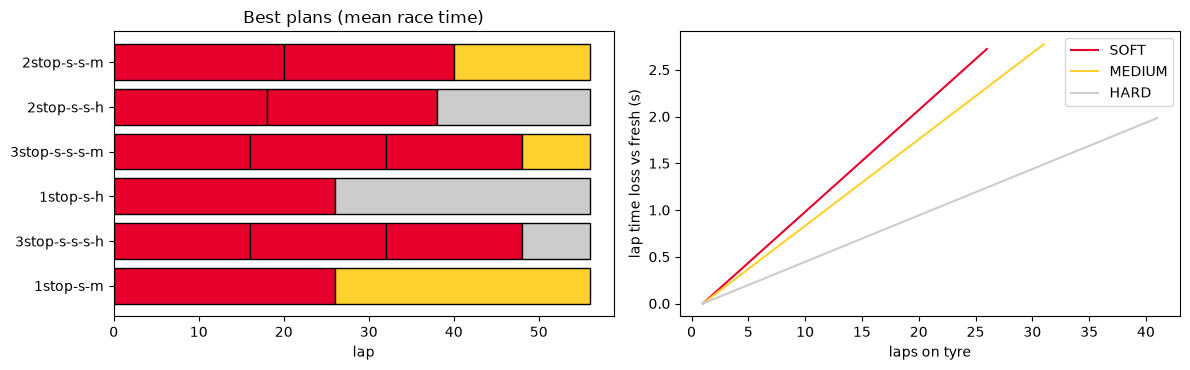

saved data/processed/2026/16/strategy_options.csv (6 rows)


1207

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
colours = {"SOFT": "#E8002D", "MEDIUM": "#FFD12E", "HARD": "#CCCCCC"}
for y, opt in enumerate(strategy_options[::-1]):
    for compound, start, end in opt["stints"]:
        axes[0].barh(y, end - start + 1, left=start - 1, color=colours[compound], edgecolor="black")
axes[0].set_yticks(range(len(strategy_options)), [o["id"] for o in strategy_options[::-1]])
axes[0].set_xlabel("lap")
axes[0].set_title("Best plans (mean race time)")
for c in DRY:
    life = np.arange(1, stint_caps[c] + 1)
    axes[1].plot(life, deg_post.loc[c, "post_mean"] * (life - 1), color=colours[c], label=c)
axes[1].set_xlabel("laps on tyre")
axes[1].set_ylabel("lap time loss vs fresh (s)")
axes[1].legend()
plt.tight_layout()
plt.show()

save_csv(strategy_table.assign(stints=lambda t: t["stints"].map(str), pit_windows=lambda t: t["pit_windows"].map(str),
                               sequence=lambda t: t["sequence"].map("-".join), lengths=lambda t: t["lengths"].map(str)),
         WEEKEND_DIR / "strategy_options.csv")
strategy_params = {
    "race_laps": RACE_LAPS, "pit_loss_s": PIT_LOSS_S, "pit_loss_sd": PIT_LOSS_SD, "fuel_gain_s_per_lap": FUEL_GAIN_S_PER_LAP,
    "stint_caps": stint_caps, "p_safety_car": P_SC,
    "degradation": deg_post.round(4).to_dict("index"), "pace_offset": off_post.round(4).to_dict("index"),
}
(WEEKEND_DIR / "strategy_params.json").write_text(json.dumps(strategy_params, indent=2))

## 9 · Fun facts

Each fact is computed from this weekend's data or from Ergast history, and carries its source.

In [34]:
# Standings after the previous round, also needed by the event document
prev_round = RACE_ROUND - 1
driver_standings = with_retry(api.get_driver_standings, season=SEASON, round=prev_round).content[0]
team_standings = with_retry(api.get_constructor_standings, season=SEASON, round=prev_round).content[0]

quali_now = quali_results[(quali_results["season"] == SEASON) & (quali_results["round"] == RACE_ROUND)].sort_values("position")
quali_now = quali_now.assign(name=quali_now["driverId"].map(driver_name), team=quali_now["constructorId"].map(team_name))
weekend_laps = pd.concat([s.laps.assign(session_id=sid) for sid, s in weekend.items()], ignore_index=True)

facts = []


def add_fact(slug, category, headline, body, source, drivers=(), teams=()):
    facts.append({"id": slug, "category": category, "headline": headline, "body": body,
                  "driver_ids": list(drivers), "team_ids": list(teams), "source": source})


Q_SOURCE = f"ergast {SEASON} R{RACE_ROUND} qualifying"

# pole
pole, second = quali_now.iloc[0], quali_now.iloc[1]
pole_time = pole[["Q1", "Q2", "Q3"]].min()
gap = second[["Q1", "Q2", "Q3"]].min() - pole_time
poles_since = int(((quali_results["driverId"] == pole["driverId"]) & (quali_results["position"] == 1)).sum())
team_poles_before = int(((quali_results["season"] == SEASON) & (quali_results["round"] < RACE_ROUND)
                         & (quali_results["constructorId"] == pole["constructorId"]) & (quali_results["position"] == 1)).sum())
add_fact("pole-sitter", "weekend", f"{pole['name']} takes pole by {gap:.3f} s",
         f"{pole_time:.3f} s in Q3, ahead of {second['name']} ({second['team']}). It is pole number {poles_since} "
         f"for {pole['name'].split()[-1]} since {FIRST_TIMING_SEASON}"
         + (f" and {pole['team']}'s first of {SEASON}." if team_poles_before == 0 else f" and {pole['team']}'s {team_poles_before + 1}th of {SEASON}."),
         Q_SOURCE, [pole["driverId"], second["driverId"]], [pole["constructorId"]])

# the championship leaders against their grid slots
leader_team = team_standings.iloc[0]
leader_slots = quali_now.loc[quali_now["constructorId"] == leader_team["constructorId"], "position"].astype(int).tolist()
if leader_slots:
    add_fact("championship-leaders-grid", "team",
             f"{team_name.get(leader_team['constructorId'], leader_team['constructorName'])} lead the constructors' but start P{min(leader_slots)}"
             + (f" and P{max(leader_slots)}" if len(leader_slots) > 1 else ""),
             f"{leader_team['constructorName']} have {leader_team['points']:.0f} points after round {prev_round}, "
             f"with {int(leader_team['wins'])} wins from {prev_round} races.",
             f"ergast {SEASON} constructor standings after round {prev_round}; {Q_SOURCE}",
             teams=[leader_team["constructorId"]])

# how tight the top of the grid is
q3 = quali_now.dropna(subset=["Q3"])
if len(q3) >= 8:
    spread = q3["Q3"].iloc[7] - q3["Q3"].iloc[0]
    add_fact("front-of-grid-spread", "weekend", f"Pole to P8 is {spread:.3f} s",
             f"{q3.iloc[0]['name']} set {q3['Q3'].iloc[0]:.3f} s in Q3, and {q3.iloc[7]['name']} in eighth "
             f"managed {q3['Q3'].iloc[7]:.3f} s.", Q_SOURCE,
             [q3.iloc[0]["driverId"], q3.iloc[7]["driverId"]])

# biggest teammate gap on the grid
teammate_gap = (quali_now.groupby("constructorId").agg(best=("position", "min"), worst=("position", "max"))
                .assign(gap=lambda t: t["worst"] - t["best"]).sort_values("gap", ascending=False).iloc[0])
gap_team = teammate_gap.name
pair = quali_now[quali_now["constructorId"] == gap_team].sort_values("position")
add_fact("teammate-gap", "team", f"{team_name[gap_team]}: {int(teammate_gap['gap'])} grid places between teammates",
         f"{pair.iloc[0]['name']} starts P{int(pair.iloc[0]['position'])}, {pair.iloc[1]['name']} P{int(pair.iloc[1]['position'])}.",
         Q_SOURCE, pair["driverId"].tolist(), [gap_team])

# top speed through the speed trap
trap = weekend_laps.dropna(subset=["SpeedST"]).sort_values("SpeedST", ascending=False).iloc[0]
trap_id = entries.set_index("Abbreviation")["driverId"][trap["Driver"]]
add_fact("top-speed-trap", "telemetry", f"{trap['SpeedST']:.0f} km/h: fastest through the speed trap",
         f"{driver_name[trap_id]} ({team_name[entries.set_index('driverId')['constructorId'][trap_id]]}) in {trap['session_id']}. "
         f"Speed trap readings from FastF1 lap data, all sessions so far.",
         f"fastf1 {SEASON} R{RACE_ROUND} laps", [trap_id], [entries.set_index("driverId")["constructorId"][trap_id]])

# track temperature
hottest = session_rows["track_temp_max"].idxmax()
add_fact("track-temperature", "weekend", f"Track temperature peaked at {session_rows['track_temp_max'].max():.0f} C",
         f"Hottest in {hottest}. Mean track temperature by session: "
         + ", ".join(f"{s} {t:.0f} C" for s, t in session_rows["track_temp_mean"].items()) + ".",
         f"fastf1 {SEASON} R{RACE_ROUND} weather")

# the race-window forecast
add_fact("race-rain-chance", "weekend", f"{P_RAIN_RACE:.0%} chance of rain in the race window",
         f"Open-Meteo forecast for the two hours from lights out: about {race_window['temperature_2m'].mean():.0f} C air, "
         f"wind {race_window['wind_speed_10m'].mean():.1f} m/s. Wet races raise the safety car odds in the incident model.",
         "open-meteo forecast")

# circuit history
if len(past_winners):
    last = past_winners.iloc[0]
    add_fact("circuit-return", "history", f"{race_row['circuitName']} returns after {SEASON - int(last['season'])} years",
             f"The last Formula 1 race there was in {int(last['season'])}, won by {last['driver_name']} for {last['team_name']}. "
             f"No car on this grid has race data there in FastF1's timing history (from {FIRST_TIMING_SEASON}).",
             f"ergast circuit {CIRCUIT_ID} race winners")
else:
    add_fact("circuit-debut", "history", f"{race_row['circuitName']} hosts its first Formula 1 race",
             "No earlier race is on record at this circuit.", f"ergast circuit {CIRCUIT_ID}")

facts_table = pd.DataFrame(facts)
save_csv(facts_table.assign(driver_ids=lambda t: t["driver_ids"].map(",".join), team_ids=lambda t: t["team_ids"].map(",".join)),
         WEEKEND_DIR / "facts.csv")
facts_table[["id", "category", "headline"]]

saved data/processed/2026/16/facts.csv (8 rows)


,id,category,headline
0,pole-sitter,weekend,Max Verstappen takes pole by 0.298 s
1,championship-leaders-grid,team,Mercedes lead the constructors' but start P4 a...
2,front-of-grid-spread,weekend,Pole to P8 is 0.741 s
3,teammate-gap,team,Audi: 7 grid places between teammates
4,top-speed-trap,telemetry,336 km/h: fastest through the speed trap
5,track-temperature,weekend,Track temperature peaked at 60 C
6,race-rain-chance,weekend,71% chance of rain in the race window
7,circuit-return,history,Sepang International Circuit returns after 9 y...


## 10 · Publish

Everything above is turned into the documents in `src/schema.py`, written to `outputs/site/v1/`, and the
round is checked as a whole. Nothing is published if validation fails.

In [35]:
def meta(artifact: str, stage: str = STAGE) -> schema.Meta:
    return schema.Meta(artifact=artifact, season=SEASON, round=RACE_ROUND, stage=stage,
                       generated_at=GENERATED_AT, run_id=RUN_ID)


def utc(ts) -> datetime:
    return pd.Timestamp(ts).tz_localize("UTC").to_pydatetime() if pd.Timestamp(ts).tzinfo is None else pd.Timestamp(ts).to_pydatetime()


def color(hex_code) -> str:
    return f"#{hex_code}" if isinstance(hex_code, str) and len(hex_code) == 6 else "#808080"


# entities: Ergast ids from FastF1, which has to agree with the qualifying table the model used
assert set(entries["driverId"]) == set(predict_rows["driverId"]), "entry list differs between FastF1 and Ergast"
team_order = team_standings["constructorId"].tolist()
teams_in_entry = sorted(entries["constructorId"].unique(), key=lambda t: team_order.index(t) if t in team_order else 99)
event_teams = [schema.Team(id=t, name=team_name[t], color=color(entries.loc[entries["constructorId"] == t, "TeamColor"].iloc[0]))
               for t in teams_in_entry]
event_drivers = [schema.Driver(id=r.driverId, code=r.Abbreviation, number=int(r.DriverNumber), first_name=r.FirstName,
                               last_name=r.LastName, team_id=r.constructorId,
                               headshot_url=r.HeadshotUrl if isinstance(r.HeadshotUrl, str) and r.HeadshotUrl else None)
                 for r in entries.itertuples()]

# circuit outline, thinned to about 150 points
keep = np.linspace(0, len(outline) - 1, 150).astype(int)
outline_points = [(round(float(outline["x"].iloc[i]), 4), round(float(outline["y"].iloc[i]), 4)) for i in keep]

event_doc = schema.EventDoc(
    meta=meta("event"), name=event["EventName"], official_name=event["OfficialEventName"], format=EVENT_FORMAT,
    circuit=schema.Circuit(
        id=CIRCUIT_ID, name=race_row["circuitName"], locality=race_row["locality"], country=race_row["country"],
        lat=float(race_row["lat"]), lon=float(race_row["long"]), length_km=round(LENGTH_KM, 3), race_laps=RACE_LAPS,
        outline=outline_points, corners=[],
        past_winners=[schema.PastWinner(season=int(r.season), driver_name=r.driver_name, team_name=r.team_name)
                      for r in past_winners.head(5).itertuples()]),
    sessions=[schema.Session(id=s["session_id"], name=s["session_name"], start_utc=utc(s["session_dt_utc"]),
                             status=session_status(s["session_dt_utc"])) for s in weekend_sessions],
    teams=event_teams, drivers=event_drivers,
    standings=schema.Standings(
        after_round=prev_round if prev_round >= 1 else None,
        drivers=[schema.DriverStanding(driver_id=r.driverId, position=int(r.position), points=float(r.points), wins=int(r.wins))
                 for r in driver_standings.itertuples()],
        teams=[schema.TeamStanding(team_id=r.constructorId, position=int(r.position), points=float(r.points), wins=int(r.wins))
               for r in team_standings.itertuples()]))

In [36]:
# weather: observed for sessions that have run, the forecast for the ones that have not
session_weather = []
for s in weekend_sessions:
    sid = s["session_id"]
    entry = {"session_id": sid, "start_utc": utc(s["session_dt_utc"])}
    if sid in summaries:
        row = summaries[sid][1].iloc[0]
        entry["observed"] = schema.ObservedWeather(
            air_temp_c_mean=float(row["air_temp_mean"]), track_temp_c_max=float(row["track_temp_max"]),
            humidity_mean=float(row["humidity_mean"] / 100), wind_speed_ms_mean=float(row["wind_speed_mean"]),
            rain_share=float(row["rain_frac"]))
    else:
        start = pd.Timestamp(entry["start_utc"])
        window = hourly[(hourly["time_utc"] >= start.floor("h")) & (hourly["time_utc"] < start + pd.Timedelta(hours=2))]
        if len(window):
            entry["forecast"] = schema.SessionForecast(
                air_temp_c=float(window["temperature_2m"].mean()), p_rain=float(window["precipitation_probability"].mean() / 100),
                wind_speed_ms=float(window["wind_speed_10m"].mean()))
    session_weather.append(schema.SessionWeather(**entry))

weather_doc = schema.WeatherDoc(
    meta=meta("weather"), source="open-meteo", issued_at=FORECAST_FETCHED_AT, sessions=session_weather,
    hourly=[schema.HourlyForecast(
        time_utc=r.time_utc.to_pydatetime(), air_temp_c=float(r.temperature_2m), p_rain=float(r.precipitation_probability / 100),
        rain_mm=float(r.precipitation), wind_speed_ms=float(r.wind_speed_10m), wind_dir_deg=float(r.wind_direction_10m % 360),
        humidity=float(r.relative_humidity_2m / 100)) for r in hourly.itertuples()],
    climatology=None)

In [37]:
# the three predictions, each with the fitted model's settings and backtest
def model_info(name: str, features: list[str], backtest_metrics: list) -> schema.ModelInfo:
    return schema.ModelInfo(name=name, version=f"{SEASON}r{RACE_ROUND:02d}-{STAGE}", trained_through=TRAINED_THROUGH,
                            features=features, calibrated=False, backtest=backtest_metrics)


# rounded rows must still sum to 1 with p_dnf, so p_dnf is what is left after rounding
finishing_rows = []
for i, r in scored.iterrows():
    probs = [round(float(p), 8) for p in position_probs[i]]
    finishing_rows.append(schema.DriverFinishPrediction(
        driver_id=r["driverId"], grid_position=int(r["q_pos"]), position_probs=probs, p_dnf=round(1 - sum(probs), 10)))
finishing_doc = schema.FinishingOrderDoc(meta=meta("finishing_order"), model=model_info("xgb-ndcg-ranker-plackett-luce", FEATURES, metrics),
                                         drivers=finishing_rows)

incidents_doc = schema.RaceIncidentsDoc(
    meta=meta("race_incidents"), model=model_info("incident-rates-rain-adjusted", ["rain_forecast", "season_race_history"], []),
    p_safety_car=rates["safety_car"]["p"], p_vsc=rates["vsc"]["p"], p_red_flag=rates["red_flag"]["p"],
    expected_safety_cars=rates["safety_car"]["expected"],
    by_lap_window=[schema.LapWindow(start_lap=int(r.start_lap), end_lap=int(r.end_lap), p_safety_car=float(r.p_safety_car))
                   for r in window_table.itertuples()],
    circuit_history=[])

fp_sessions_used = fp_runs.groupby("Compound")["session"].agg(lambda x: sorted(set(x))).to_dict()
strategy_doc = schema.StrategyDoc(
    meta=meta("strategy"), model=model_info("stint-simulation", ["fp_long_run_degradation", "race_degradation_prior", "pit_lane_time"], []),
    race_laps=RACE_LAPS, pit_loss_s=PIT_LOSS_S, compounds_available=None,
    options=[schema.StrategyOption(
        id=o["id"], stints=[schema.Stint(compound=c, start_lap=a, end_lap=b) for c, a, b in o["stints"]],
        expected_time_delta_s=o["expected_time_delta_s"], p_best=o["p_best"],
        pit_windows=[schema.PitWindow(stop=j + 1, earliest_lap=lo, latest_lap=hi) for j, (lo, hi) in enumerate(o["pit_windows"])])
        for o in strategy_options],
    degradation=[schema.DegradationCurve(
        compound=c, tyre_life=list(range(1, stint_caps[c] + 1)),
        lap_delta_s=[round(float(deg_post.loc[c, "post_mean"] * (life - 1)), 4) for life in range(1, stint_caps[c] + 1)],
        source_sessions=fp_sessions_used.get(c, [])) for c in DRY])

facts_doc = schema.FactsDoc(meta=meta("facts"), facts=[schema.Fact(**f) for f in facts])


def seconds(value):
    return None if pd.isna(value) else float(value)


results_doc = schema.ResultsDoc(
    meta=meta("results"),
    qualifying=[schema.QualiRow(driver_id=r.driverId, position=int(r.position), q1_s=seconds(r.Q1), q2_s=seconds(r.Q2), q3_s=seconds(r.Q3))
                for r in quali_now.itertuples()])

In [38]:
# manifest and season index
def ready(section: str) -> schema.SectionStatus:
    return schema.SectionStatus(status="ready", path=schema.section_path(section, STAGE), stage=STAGE, updated_at=GENERATED_AT)


manifest_doc = schema.RaceManifest(
    meta=meta("manifest"), event_name=event["EventName"], format=EVENT_FORMAT, race_start_utc=RACE_START.to_pydatetime(),
    sections={
        "event": ready("event"), "weather": ready("weather"), "finishing_order": ready("finishing_order"),
        "qualifying": schema.SectionStatus(status="not_applicable", message="Qualifying has run. The result is in the results panel."),
        "race_incidents": ready("race_incidents"), "strategy": ready("strategy"), "facts": ready("facts"), "results": ready("results"),
    })


def round_status(row) -> str:
    if int(row["RoundNumber"]) == RACE_ROUND:
        return "current"
    return "completed" if row["Session5DateUtc"] + pd.Timedelta(hours=3) < now else "upcoming"


ergast_season = with_retry(api.get_race_schedule, season=SEASON, limit=100).set_index("round")
index_doc = schema.SeasonIndex(
    meta=schema.Meta(artifact="index", season=SEASON, generated_at=GENERATED_AT, run_id=RUN_ID), current_round=RACE_ROUND,
    rounds=[schema.RoundSummary(
        round=int(r["RoundNumber"]), event_name=r["EventName"], country=r["Country"], circuit_id=ergast_season.loc[int(r["RoundNumber"]), "circuitId"],
        format=r["EventFormat"], race_start_utc=utc(r["Session5DateUtc"]), status=round_status(r),
        manifest_path=(f"{schema.round_dir(SEASON, int(r['RoundNumber']))}/manifest.json"
                       if (SITE_DIR / schema.round_dir(SEASON, int(r["RoundNumber"])) / "manifest.json").exists()
                       or int(r["RoundNumber"]) == RACE_ROUND else None))
        for _, r in schedule.iterrows()])

In [39]:
# write, then validate the round as a whole
round_docs = {
    "manifest.json": manifest_doc, "event.json": event_doc, "weather.json": weather_doc, "facts.json": facts_doc,
    "results.json": results_doc, schema.section_path("finishing_order", STAGE): finishing_doc,
    schema.section_path("race_incidents", STAGE): incidents_doc, schema.section_path("strategy", STAGE): strategy_doc,
}
for rel, doc in round_docs.items():
    path = SITE_DIR / WEEKEND / rel
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(doc.model_dump_json(indent=2) + "\n")
(SITE_DIR / "index.json").write_text(index_doc.model_dump_json(indent=2) + "\n")

problems = schema.check_round(SITE_DIR / WEEKEND)
schema.load(SITE_DIR / "index.json", "index")
for problem in problems:
    print(f"x {problem}")
assert not problems, "round failed validation"
print(f"{SITE_DIR.relative_to(ROOT) / WEEKEND}: OK ({len(round_docs)} documents + index)")
sizes = {rel: (SITE_DIR / WEEKEND / rel).stat().st_size for rel in round_docs}
print({rel: f"{size / 1024:.1f} KB" for rel, size in sizes.items()})

outputs/site/v1/2026/16: OK (8 documents + index)
{'manifest.json': '2.1 KB', 'event.json': '21.0 KB', 'weather.json': '12.8 KB', 'facts.json': '3.3 KB', 'results.json': '3.1 KB', 'finishing_order/Q.json': '16.2 KB', 'race_incidents/Q.json': '1.2 KB', 'strategy/Q.json': '7.7 KB'}


## 11 · Race result against the prediction

Run after the race. Nothing is refitted: the model only saw races before this one, and the weather is the
forecast saved before the start, so a rerun reproduces the pre-race prediction. Each prediction is graded
against the result, and this race is then added to the backtest as a 40th, genuinely unseen, test.

How the grade works, in plain terms:
- **Rank correlation, top-3 overlap, mean position error:** is the order right? Compared with reading qualifying order.
- **Winner hit:** did the top pick win?
- **Brier score:** how good are the percentages. Lower is better, and 0 means certain and right.
- **Probability given to what happened:** how surprised the model was.

One race cannot show the model is good or bad. It is graded alone, then placed among the 39 backtest races.

In [40]:
# FastF1 logs a line per driver whenever it corrects race data (stint fixes, finish times), which buries the output
logging.getLogger("fastf1").setLevel(logging.ERROR)
RACE_FINISHED = session_status(weekend_sessions[-1]["session_dt_utc"], minutes=180) == "completed"
assert RACE_FINISHED, "the race has not finished yet: run sections 11 and 12 after it"

race = fastf1.get_session(SEASON, RACE_ROUND, "R")
race.load(laps=True, telemetry=False, weather=True, messages=True)
_, race_summary = summarize_session(race)
race_summary = race_summary.iloc[0]

# "not classified" follows Ergast's rule (no number in the classification), the label the models were trained on
res = race.results
actual = pd.DataFrame({
    "driverId": res["DriverId"], "code": res["Abbreviation"], "grid": res["GridPosition"].astype(int),
    "finish": res["Position"].astype(int), "classified_as": res["ClassifiedPosition"].astype(str),
    "status": res["Status"], "points": res["Points"]})
actual["dnf"] = (~actual["classified_as"].str.isdigit()).astype(int)
assert len(actual) == len(prediction) and set(actual["driverId"]) == set(prediction["driverId"])
print(f"{race.event['EventName']}: {race.total_laps} laps, {int(actual['dnf'].sum())} not classified, "
      f"{race_summary['duration_min']:.0f} min including {race_summary['sc_min']:.0f} min behind the safety car")

Bahrain Grand Prix: 55 laps, 2 not classified, 107 min including 23 min behind the safety car


In [41]:
# Driver by driver: prediction next to result. p_actual is the probability the model gave to what really
# happened to that driver: the exact finishing place, or retiring
compare = prediction.reset_index(drop=True).assign(predicted_rank=lambda t: t.index + 1).merge(
    actual, on="driverId", suffixes=("", "_actual"))
compare["p_actual"] = [row.p_dnf if row.dnf else position_table.loc[row.driverId, f"P{row.finish}"] for row in compare.itertuples()]
compare["finish_error"] = (compare["finish"] - compare["predicted_rank"]).where(compare["dnf"] == 0)

# p_tail: the chance of a result at least this far from the prediction, on the same side. An exact place is
# unlikely for almost everyone, so this is the fairer measure of surprise. Worse than predicted counts retiring too
n_cars = len(compare)
tail = []
for row in compare.itertuples():
    if row.dnf:
        tail.append(row.p_dnf)
    elif row.finish > row.predicted_rank:
        tail.append(position_table.loc[row.driverId, [f"P{k}" for k in range(row.finish, n_cars + 1)]].sum() + row.p_dnf)
    else:
        tail.append(position_table.loc[row.driverId, [f"P{k}" for k in range(1, row.finish + 1)]].sum())
compare["p_tail"] = tail

compare = compare.sort_values("finish").reset_index(drop=True)
save_csv(compare, WEEKEND_DIR / "race_vs_prediction.csv")
compare[["code", "grid", "q_pos", "predicted_rank", "finish", "status", "p_win", "p_podium", "p_dnf", "p_actual", "p_tail", "finish_error"]].round(3)

saved data/processed/2026/16/race_vs_prediction.csv (22 rows)


,code,grid,q_pos,predicted_rank,finish,status,p_win,p_podium,p_dnf,p_actual,p_tail,finish_error
0,VER,1,1.0,2,1,Finished,0.360,0.893,0.090,0.360,0.360,-1.0
1,ANT,3,4.0,3,2,Finished,0.107,0.794,0.055,0.212,0.319,-1.0
2,HAM,2,2.0,1,3,Finished,0.506,0.937,0.054,0.097,0.161,2.0
3,LEC,4,5.0,4,4,Finished,0.008,0.112,0.090,0.243,0.355,0.0
4,HAD,8,3.0,5,5,Finished,0.008,0.106,0.102,0.239,0.577,0.0
5,PIA,6,7.0,8,6,Finished,0.001,0.020,0.134,0.138,0.291,-2.0
6,LAW,11,11.0,11,7,Finished,0.000,0.002,0.097,0.054,0.092,-4.0
7,ALO,12,12.0,12,8,Finished,0.000,0.000,0.091,0.040,0.067,-4.0
8,NOR,5,6.0,6,9,Finished,0.007,0.093,0.135,0.006,0.142,3.0
9,LIN,22,16.0,17,10,Finished,0.000,0.000,0.134,0.038,0.077,-7.0


In [42]:
# Order and probabilities for this race alone
race_frame = compare.assign(position=compare["finish"])
this_race = race_metrics(race_frame)

y_win = ((compare["finish"] == 1) & (compare["dnf"] == 0)).astype(float)
y_podium = ((compare["finish"] <= 3) & (compare["dnf"] == 0)).astype(float)
slot_win = slot_rate["win"].reindex(compare["q_pos"]).fillna(0).to_numpy()
slot_podium = slot_rate["podium"].reindex(compare["q_pos"]).fillna(0).to_numpy()
winner = compare.loc[y_win == 1].iloc[0]

# surprise in nats: -ln(probability given to what happened). 0 = certain, higher = more surprised
surprise = pd.Series({
    "model": -np.log(winner["p_win"]),
    "grid-slot rate": -np.log(slot_win[y_win.to_numpy() == 1][0]),
    "everyone equal": -np.log(1 / len(compare))})
print(f"winner {winner['code']} (grid P{winner['grid']}, qualified P{int(winner['q_pos'])}): the model gave {winner['p_win']:.0%}, "
      f"the grid-slot rate {slot_win[y_win.to_numpy() == 1][0]:.0%}")
display(surprise.round(2).to_frame("surprise at the winner (lower is better)"))

podium_pred, podium_real = list(compare.nsmallest(3, "predicted_rank")["code"]), list(compare.nsmallest(3, "finish")["code"])
print(f"predicted top 3 {podium_pred} | actual podium {podium_real} | {len(set(podium_pred) & set(podium_real))} of 3 right")

# where this race sits among the backtest races, for the model and for plain grid order. A race that is hard
# for the grid order too (rain, safety cars) is a hard race, whatever the model did
harder_than = lambda column, higher_is_better: float((per_race[column] > this_race[column]).mean() if higher_is_better
                                                      else (per_race[column] < this_race[column]).mean())
print(f"rank correlation: model {this_race['spearman_model']:.2f}, grid order {this_race['spearman_grid']:.2f}")
print(f"  a harder race for the model than {harder_than('spearman_model', True):.0%} of the 39 backtest races, "
      f"and for grid order than {harder_than('spearman_grid', True):.0%}")
print(f"mean position error: model {this_race['mae_model']:.2f}, grid order {this_race['mae_grid']:.2f}")
print(f"  larger than in {harder_than('mae_model', False):.0%} of the 39 backtest races for the model, "
      f"{harder_than('mae_grid', False):.0%} for grid order")

winner VER (grid P1, qualified P1): the model gave 36%, the grid-slot rate 52%


,surprise at the winner (lower is better)
model,1.02
grid-slot rate,0.65
everyone equal,3.09


predicted top 3 ['HAM', 'VER', 'ANT'] | actual podium ['VER', 'ANT', 'HAM'] | 3 of 3 right
rank correlation: model 0.66, grid order 0.67
  a harder race for the model than 79% of the 39 backtest races, and for grid order than 72%
mean position error: model 3.60, grid order 3.70
  larger than in 95% of the 39 backtest races for the model, 95% for grid order


In [43]:
# Scorecard: this race alone, then the backtest with this race added as a 40th out-of-sample race
race_probs = compare.assign(y_win=y_win, y_podium=y_podium)[["driverId", "q_pos", "p_win", "p_podium", "y_win", "y_podium"]]
pool = pd.concat([prob_bt[race_probs.columns], race_probs], ignore_index=True)
slot_pool = pool.assign(p_win=slot_rate["win"].reindex(pool["q_pos"]).fillna(0).to_numpy(),
                        p_podium=slot_rate["podium"].reindex(pool["q_pos"]).fillna(0).to_numpy())
slot_race = race_probs.assign(p_win=slot_win, p_podium=slot_podium)
per_race_40 = pd.concat([per_race, pd.DataFrame([this_race])], ignore_index=True).mean()
b_model, b_slot = brier_pair(pool), brier_pair(slot_pool)
b_race_model, b_race_slot = brier_pair(race_probs), brier_pair(slot_race)

scorecard = pd.DataFrame([
    ("rank correlation (higher better)", this_race["spearman_model"], this_race["spearman_grid"], per_race_40["spearman_model"], per_race_40["spearman_grid"]),
    ("winner hit rate (higher better)", this_race["winner_model"], this_race["winner_grid"], per_race_40["winner_model"], per_race_40["winner_grid"]),
    ("top-3 overlap (higher better)", this_race["top3_model"], this_race["top3_grid"], per_race_40["top3_model"], per_race_40["top3_grid"]),
    ("mean position error (lower better)", this_race["mae_model"], this_race["mae_grid"], per_race_40["mae_model"], per_race_40["mae_grid"]),
    ("Brier win (lower better)", b_race_model[0], b_race_slot[0], b_model[0], b_slot[0]),
    ("Brier podium (lower better)", b_race_model[1], b_race_slot[1], b_model[1], b_slot[1]),
], columns=["measure", "this race: model", "this race: baseline", "40 races: model", "40 races: baseline"]).set_index("measure")
save_csv(scorecard.reset_index(), WEEKEND_DIR / "post_race_scorecard.csv")
display(scorecard.round(3))

saved data/processed/2026/16/post_race_scorecard.csv (6 rows)


,this race: model,this race: baseline,40 races: model,40 races: baseline
measure,,,,
rank correlation (higher better),0.656,0.671,0.779,0.759
winner hit rate (higher better),0.000,1.000,0.650,0.725
top-3 overlap (higher better),1.000,0.667,0.742,0.725
mean position error (lower better),3.600,3.700,2.254,2.312
Brier win (lower better),0.031,0.013,0.026,0.025
Brier podium (lower better),0.004,0.041,0.058,0.062


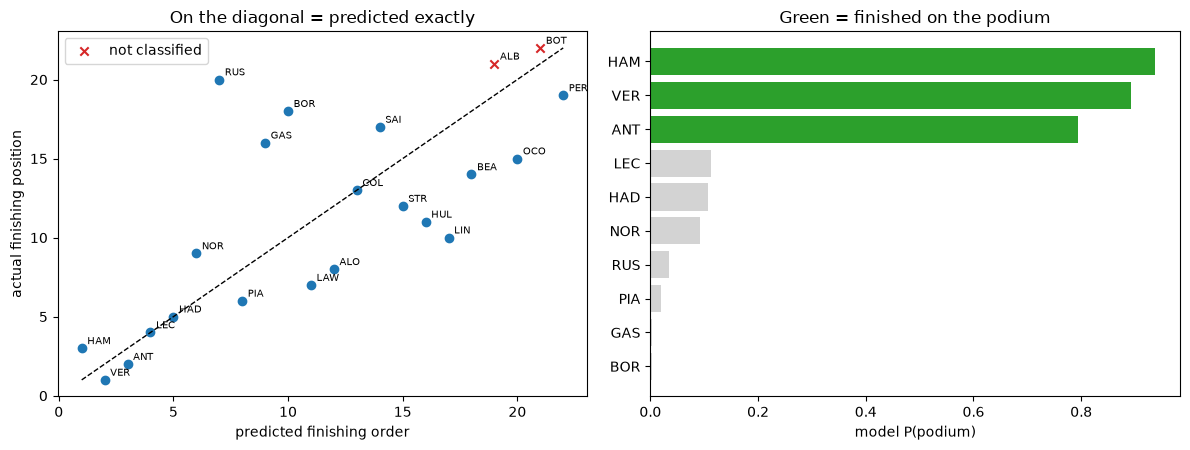

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
ax = axes[0]
classified, retired = compare[compare["dnf"] == 0], compare[compare["dnf"] == 1]
ax.plot([1, len(compare)], [1, len(compare)], "k--", lw=1)
ax.scatter(classified["predicted_rank"], classified["finish"], color="tab:blue")
ax.scatter(retired["predicted_rank"], retired["finish"], color="tab:red", marker="x", label="not classified")
for r in compare.itertuples():
    ax.annotate(r.code, (r.predicted_rank, r.finish), textcoords="offset points", xytext=(4, 3), fontsize=7)
ax.set_xlabel("predicted finishing order")
ax.set_ylabel("actual finishing position")
ax.set_title("On the diagonal = predicted exactly")
ax.legend()

ax = axes[1]
top = compare.nsmallest(10, "predicted_rank").iloc[::-1]
ax.barh(top["code"], top["p_podium"], color=np.where(top["finish"] <= 3, "tab:green", "lightgray"))
ax.set_xlabel("model P(podium)")
ax.set_title("Green = finished on the podium")
plt.tight_layout()
plt.show()

In [45]:
# The other panels: incidents, weather, laps and strategy against what happened
actual_incident, actual_stints, _ = load_race_history(SEASON, RACE_ROUND)
actual_incident = actual_incident.iloc[0]
sc_starts_actual = json.loads(actual_incident["sc_start_laps"])

# incidents: probability given to "at least one" against what happened
incident_check = pd.DataFrame([
    {"incident": name, "predicted P(at least one)": rates[name]["p"], "predicted expected number": rates[name]["expected"],
     "actual number": int(actual_incident[col]), "Brier": (rates[name]["p"] - float(actual_incident[col] > 0)) ** 2}
    for name, col in INCIDENT_COLS.items()]).set_index("incident")
display(incident_check.round(3))
dry_rates, wet_rates = incident_rates(0.0), incident_rates(1.0)
print(f"P(safety car): {dry_rates['safety_car']['p']:.0%} if dry, {wet_rates['safety_car']['p']:.0%} if wet, "
      f"{rates['safety_car']['p']:.0%} used ({P_RAIN_RACE:.0%} rain chance)")
for lap in sc_starts_actual:
    window = window_table[(window_table["start_lap"] <= lap) & (window_table["end_lap"] >= lap)].iloc[0]
    print(f"safety car out on lap {lap}: the model gave laps {window['start_lap']}-{window['end_lap']} {window['p_safety_car']:.0%}")

# weather: forecast against the race
started_on_inters = int((race.laps.sort_values("LapNumber").groupby("Driver")["Compound"].first() == "INTERMEDIATE").sum())
print(f"rain: forecast {P_RAIN_RACE:.0%} for the race window | {started_on_inters} of {len(actual)} cars started on intermediates, "
      f"{race_summary['wet_laps_frac']:.0%} of all laps run on them")
print(f"air temperature: forecast {race_window['temperature_2m'].mean():.1f} C | observed {race_summary['air_temp_mean']:.1f} C")
print(f"wind: forecast {race_window['wind_speed_10m'].mean():.1f} m/s | observed {race_summary['wind_speed_mean']:.1f} m/s")

# distance and strategy
print(f"race laps: estimated {RACE_LAPS} from the telemetry lap length | actual {race.total_laps}")
stops_actual = actual_stints.groupby("Driver").size() - 1
actual_stints = actual_stints.assign(stint_laps=lambda t: t["end_lap"] - t["start_lap"] + 1)
longest = actual_stints[~actual_stints["is_final"]].groupby("Compound")["stint_laps"].max()
print(f"stops per car: median {stops_actual.median():.0f}, most {stops_actual.max()}, "
      f"counting the switch off intermediates and the safety car stops | predicted best plan: {strategy_options[0]['id']}")
print("longest slick stint by compound (laps): actual vs the cap used in the simulation")
print({c: (int(longest.get(c, 0)), stint_caps[c]) for c in DRY})
order_codes = compare["code"].tolist()
plans = (actual_stints.sort_values(["Driver", "Stint"]).assign(piece=lambda t: t["Compound"].astype(str).replace({"None": "?", "nan": "?"}).str[0] + t["stint_laps"].astype(int).astype(str))
         .groupby("Driver")["piece"].agg(" ".join).reindex(order_codes))
plans.head(10).to_frame("stints (I = intermediate, S/M/H = slick, laps)")

,predicted P(at least one),predicted expected number,actual number,Brier
incident,,,,
safety_car,0.527,0.889,2,0.224
vsc,0.563,1.087,1,0.191
red_flag,0.135,0.135,0,0.018


P(safety car): 54% if dry, 52% if wet, 53% used (71% rain chance)
safety car out on lap 8: the model gave laps 1.0-10.0 31%
safety car out on lap 44: the model gave laps 41.0-50.0 16%
rain: forecast 71% for the race window | 9 of 22 cars started on intermediates, 11% of all laps run on them
air temperature: forecast 26.2 C | observed 27.1 C
wind: forecast 1.6 m/s | observed 1.8 m/s
race laps: estimated 56 from the telemetry lap length | actual 55
stops per car: median 3, most 7, counting the switch off intermediates and the safety car stops | predicted best plan: 2stop-s-s-m
longest slick stint by compound (laps): actual vs the cap used in the simulation
{'SOFT': (31, 26), 'MEDIUM': (24, 31), 'HARD': (25, 41)}


,"stints (I = intermediate, S/M/H = slick, laps)"
Driver,
VER,I9 S24 S10 S12
ANT,I9 M24 S11 S11
HAM,S31 M12 S12
LEC,S3 I6 S19 ?15 S12
HAD,I9 S22 ?13 S11
PIA,M2 I7 H24 H12 M10
LAW,I9 H21 H15 S10
ALO,M9 H22 ?14 S10
NOR,M9 H25 S11 S10


## 12 · Post-race fun facts

Computed from the race itself, and from how it compared with the prediction.

In [46]:
by_code = entries.set_index("Abbreviation")["driverId"]
team_of = entries.set_index("driverId")["constructorId"]
laps_r = race.laps
post_facts = []


def add_post_fact(slug, category, headline, body, source, drivers=(), teams=()):
    post_facts.append({"id": slug, "category": category, "headline": headline, "body": body,
                       "driver_ids": list(drivers), "team_ids": list(teams), "source": source})


R_SOURCE = f"fastf1 {SEASON} R{RACE_ROUND} race"
lap_str = lambda seconds: f"{int(seconds // 60)}:{seconds % 60:06.3f}"
n_cars = len(compare)

# the winner
w_id = winner["driverId"]
runner_up = compare.loc[compare["finish"] == 2].iloc[0]
margin = res.loc[res["Position"] == 2, "Time"].iloc[0].total_seconds()
before_this_race = ~((race_results["season"] == SEASON) & (race_results["round"] >= RACE_ROUND))
team_wins_before = int(((race_results["constructorId"] == team_of[w_id]) & (race_results["position"] == 1)
                        & (race_results["season"] == SEASON) & before_this_race).sum())
wins_since = int(((race_results["driverId"] == w_id) & (race_results["position"] == 1) & before_this_race).sum()) + 1
grid_text = "pole" if winner["grid"] == 1 else f"P{winner['grid']}"
add_post_fact("race-winner", "weekend", f"{driver_name[w_id]} wins from {grid_text} by {margin:.3f} s",
              f"Ahead of {driver_name[runner_up['driverId']]} after {race.total_laps} laps. Win number {wins_since} since {FIRST_TIMING_SEASON}, and "
              + (f"{team_name[team_of[w_id]]}'s first of {SEASON}." if team_wins_before == 0 else f"{team_name[team_of[w_id]]}'s win number {team_wins_before + 1} of {SEASON}."),
              R_SOURCE, [w_id], [team_of[w_id]])

# laps led
led = laps_r[laps_r["Position"] == 1].groupby("Driver")["LapNumber"].nunique().sort_values(ascending=False)
led_text = ", ".join(f"{driver_name[by_code[c]].split()[-1]} {n}" for c, n in led.items())
add_post_fact("laps-led", "weekend", f"{driver_name[by_code[led.index[0]]]} led {led.iloc[0]} of {race.total_laps} laps",
              f"Laps led: {led_text}.", R_SOURCE, [by_code[c] for c in led.index])

# neutralisations and the wet start
sc_laps_n = laps_r.loc[laps_r["TrackStatus"].str.contains("4", na=False), "LapNumber"].nunique()
add_post_fact("neutralised-laps", "weekend",
              f"{int(race_summary['sc_n'])} safety cars and {int(race_summary['vsc_n'])} VSC took {race_summary['sc_min'] + race_summary['vsc_min']:.0f} minutes",
              f"{sc_laps_n} of {race.total_laps} laps ran behind the safety car. The model expected {rates['safety_car']['expected']:.1f} safety cars and gave "
              f"{rates['safety_car']['p']:.0%} to at least one.", R_SOURCE)
last_inter = int(laps_r.loc[laps_r["Compound"] == "INTERMEDIATE", "LapNumber"].max())
add_post_fact("wet-start", "weekend", f"{started_on_inters} of {n_cars} cars started on intermediates",
              f"Intermediates were used up to lap {last_inter}. Race control announced a 90% rain risk before the start, "
              f"the forecast used here said {P_RAIN_RACE:.0%}.", f"{R_SOURCE}; open-meteo forecast")

# biggest mover and faller, by grid slot to classification
move = compare.assign(change=lambda t: t["grid"].replace(0, n_cars) - t["finish"])
up, down = move.loc[move["change"].idxmax()], move.loc[move["change"].idxmin()]
add_post_fact("biggest-mover", "driver", f"{driver_name[up['driverId']]} gained {int(up['change'])} places",
              f"From P{up['grid']} on the grid to P{up['finish']}. Biggest drop: {driver_name[down['driverId']]}, P{down['grid']} to P{down['finish']}"
              f" ({down['status'].lower()}).", R_SOURCE, [up["driverId"], down["driverId"]])

# fastest lap and pit stops
fastest = laps_r.dropna(subset=["LapTime"]).sort_values("LapTime").iloc[0]
fl_seconds = fastest["LapTime"].total_seconds()
add_post_fact("fastest-lap", "telemetry", f"Fastest lap {lap_str(fl_seconds)} on lap {int(fastest['LapNumber'])}",
              f"{driver_name[by_code[fastest['Driver']]]} on {str(fastest['Compound']).lower()}s. Pole time in qualifying was {lap_str(pole_time)}.",
              R_SOURCE, [by_code[fastest["Driver"]]])
pit_race, _ = with_retry(collect_pages, api.get_pit_stops, season=SEASON, round=RACE_ROUND)
stops_by_driver = pit_race.groupby("driverId").size().sort_values(ascending=False)
add_post_fact("pit-stops", "team", f"{len(pit_race)} pit stops, {stops_by_driver.iloc[0]} for {driver_name[stops_by_driver.index[0]]}",
              f"Median pit-lane time {pd.to_timedelta(pit_race['duration']).dt.total_seconds().median():.1f} s. "
              f"Most cars stopped {int(stops_by_driver.median())} times, against {len(strategy_options[0]['lengths']) - 1} in the pre-race best plan.",
              f"ergast {SEASON} R{RACE_ROUND} pit stops", [stops_by_driver.index[0]])

# the track
practice_track = session_rows.loc[[s for s in session_rows.index if s.startswith("Practice")], "track_temp_mean"].mean()
race_track = race.weather_data.loc[race.weather_data["TrackTemp"] > 0, "TrackTemp"].mean()
add_post_fact("track-cooled", "weekend", f"Track {practice_track - race_track:.0f} C cooler than in practice",
              f"{race_track:.0f} C on average in the race against {practice_track:.0f} C across the three practice sessions, "
              f"so the tyre wear measured on Friday came from a much hotter track.",
              R_SOURCE)

# the prediction
surprise_row = compare.loc[compare["p_tail"].idxmin()]
side = "out" if surprise_row["dnf"] else f"in P{surprise_row['finish']}"
direction = "retire" if surprise_row["dnf"] else ("finish this high" if surprise_row["finish_error"] < 0 else "finish this low")
add_post_fact("model-podium", "weekend", f"Model's top three: {len(set(podium_pred) & set(podium_real))} of 3 on the podium",
              f"Predicted {', '.join(podium_pred)}, actual {', '.join(podium_real)}. Winner got {winner['p_win']:.0%} from the model.",
              f"race result against stage {STAGE} prediction", [by_code[c] for c in podium_real])
add_post_fact("model-surprise", "driver", f"Biggest surprise: {driver_name[surprise_row['driverId']]} {side}",
              f"The model gave a {surprise_row['p_tail']:.1%} chance to a result this extreme: {direction}. "
              f"Predicted P{surprise_row['predicted_rank']}, started P{surprise_row['grid']}.",
              f"race result against stage {STAGE} prediction", [surprise_row["driverId"]])

# the championship
after = with_retry(api.get_driver_standings, season=SEASON, round=RACE_ROUND).content[0]
rounds_left = len(schedule) - RACE_ROUND
add_post_fact("title-race", "driver", f"{driver_name[after.iloc[0]['driverId']]} leads by {after.iloc[0]['points'] - after.iloc[1]['points']:.0f} points",
              f"{rounds_left} rounds left. {driver_name[after.iloc[1]['driverId']]} is second on {after.iloc[1]['points']:.0f}, "
              f"{driver_name[w_id]} moves to {after.set_index('driverId').loc[w_id, 'position']}th on {after.set_index('driverId').loc[w_id, 'points']:.0f}.",
              f"ergast {SEASON} driver standings after round {RACE_ROUND}", [after.iloc[0]["driverId"], after.iloc[1]["driverId"], w_id])

post_facts_doc = schema.FactsDoc(meta=meta("facts", stage="R"), facts=[schema.Fact(**f) for f in post_facts])
(WEEKEND_DIR / "facts_R.json").write_text(post_facts_doc.model_dump_json(indent=2) + "\n")
save_csv(pd.DataFrame(post_facts).assign(driver_ids=lambda t: t["driver_ids"].map(",".join), team_ids=lambda t: t["team_ids"].map(",".join)),
         WEEKEND_DIR / "post_race_facts.csv")
pd.DataFrame(post_facts)[["id", "headline", "body"]]

saved data/processed/2026/16/post_race_facts.csv (11 rows)


,id,headline,body
0,race-winner,Max Verstappen wins from pole by 2.307 s,Ahead of Kimi Antonelli after 55 laps. Win num...
1,laps-led,Max Verstappen led 43 of 55 laps,"Laps led: Verstappen 43, Antonelli 11, Piastri 1."
2,neutralised-laps,2 safety cars and 1 VSC took 28 minutes,13 of 55 laps ran behind the safety car. The m...
3,wet-start,9 of 22 cars started on intermediates,Intermediates were used up to lap 9. Race cont...
4,biggest-mover,Arvid Lindblad gained 12 places,From P22 on the grid to P10. Biggest drop: Geo...
5,fastest-lap,Fastest lap 1:38.220 on lap 55,Max Verstappen on softs. Pole time in qualifyi...
6,pit-stops,"73 pit stops, 7 for Sergio Perez",Median pit-lane time 28.3 s. Most cars stopped...
7,track-cooled,Track 20 C cooler than in practice,35 C on average in the race against 54 C acros...
8,model-podium,Model's top three: 3 of 3 on the podium,"Predicted HAM, VER, ANT, actual VER, ANT, HAM...."
9,model-surprise,Biggest surprise: Fernando Alonso in P8,The model gave a 6.7% chance to a result this ...
